# DiMLex analysis of model justifications

This notebook:

1. assigns every DiMLex marker to one broad category using its most frequent broad sense;
2. prints markers with exact category ties clearly before the override cell;
3. checks how often multi-category markers occur in the justifications;
4. allows optional manual category overrides;
5. measures justification length and marker usage;
6. treats every run as a separate set of **191 justifications**;
7. reports stochastic results as the **mean and standard deviation across the three runs**;
8. keeps the single greedy run separate;
9. reports both:
   - marker frequency;
   - justification coverage, where a category is counted at most once per justification;
10. builds directional conditional co-occurrence matrices:
    - row = category already observed;
    - column = probability that the other category is also present;
    - diagonal left empty;
11. saves a small set of informative tables in each model's `prompt_v4/justification_analysis` folder;
12. displays plots without saving them.

The four broad categories are:

- `Contingency`
- `Comparison`
- `Expansion`
- `Temporal`

Discontinuous entries such as `if ... then` are documented but not matched as ordinary phrases, to avoid double-counting their component words.


In [1]:
# ============================================================
# 1. Build provisional DiMLex categories
# ============================================================

from pathlib import Path
import re
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Paths
# -----------------------------

def find_repo_root(start=None, repo_name="masters_thesis_sdg"):
    """Walk upward from the working directory to the repository root, so this
    notebook runs from any machine or checkout location."""
    current = (start or Path.cwd()).resolve()

    while True:
        if current.name == repo_name:
            return current

        if current.parent == current:
            raise FileNotFoundError(
                f"Could not find repo root {repo_name!r} above {Path.cwd()}"
            )

        current = current.parent


REPO_ROOT = find_repo_root()
print("REPO_ROOT:", REPO_ROOT)

DIMLEX_FOLDER = (
    REPO_ROOT
    / "src"
    / "justification_analysis"
)

DIMLEX_XML_PATH = DIMLEX_FOLDER / "en_dimlex.xml"

if not DIMLEX_XML_PATH.exists():
    raise FileNotFoundError(
        f"DiMLex XML file not found:\n{DIMLEX_XML_PATH}"
    )


# -----------------------------
# Parse the XML
# -----------------------------

tree = ET.parse(DIMLEX_XML_PATH)
root = tree.getroot()

sense_rows = []

for entry in root.findall("entry"):
    marker = entry.get("word", "").strip().lower()

    if not marker:
        continue

    orthographies = entry.findall("./orths/orth")

    is_discontinuous = (
        any(
            orthography.get("type") == "discont"
            for orthography in orthographies
        )
        or "/" in marker
    )

    for relation in entry.findall(".//pdtb2_relation"):
        full_sense = relation.get("sense")

        if not full_sense:
            continue

        # Keep only the highest-level DiMLex category.
        top_level = full_sense.split(".")[0].strip().title()

        frequency = pd.to_numeric(
            relation.get("pdtb_freq"),
            errors="coerce",
        )

        sense_rows.append(
            {
                "marker": marker,
                "top_level": top_level,
                "full_sense": full_sense,
                "frequency": frequency,
                "is_discontinuous": is_discontinuous,
            }
        )


dimlex_senses_df = pd.DataFrame(sense_rows)


# -----------------------------
# Sum evidence by marker and broad category
# -----------------------------

marker_category_scores_df = (
    dimlex_senses_df
    .groupby(
        ["marker", "top_level", "is_discontinuous"],
        as_index=False,
    )
    .agg(
        summed_frequency=(
            "frequency",
            lambda values: values.sum(min_count=1),
        ),
        n_sense_entries=("full_sense", "size"),
    )
)


# -----------------------------
# Assign one provisional category to every marker
# -----------------------------

assignment_rows = []

for marker, marker_group in marker_category_scores_df.groupby(
    "marker",
    sort=True,
):
    marker_group = marker_group.copy()

    has_frequency = (
        marker_group["summed_frequency"].notna().any()
        and marker_group["summed_frequency"].fillna(0).sum() > 0
    )

    if has_frequency:
        marker_group["assignment_score"] = (
            marker_group["summed_frequency"].fillna(0)
        )
        assignment_method = "highest summed DiMLex frequency"
    else:
        marker_group["assignment_score"] = (
            marker_group["n_sense_entries"].astype(float)
        )
        assignment_method = "largest number of DiMLex sense entries"

    marker_group = (
        marker_group
        .sort_values(
            ["assignment_score", "top_level"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )

    highest_score = marker_group.loc[0, "assignment_score"]

    winning_categories = marker_group.loc[
        marker_group["assignment_score"].eq(highest_score),
        "top_level",
    ].tolist()

    # Exact ties are resolved alphabetically for reproducibility.
    # They remain explicitly flagged for inspection.
    provisional_category = winning_categories[0]
    exact_tie = len(winning_categories) > 1

    total_score = marker_group["assignment_score"].sum()

    dominance_share = (
        highest_score / total_score
        if total_score > 0
        else np.nan
    )

    category_scores = " | ".join(
        f"{row.top_level}: {row.assignment_score:g}"
        for row in marker_group.itertuples()
    )

    possible_senses = sorted(
        dimlex_senses_df.loc[
            dimlex_senses_df["marker"].eq(marker),
            "full_sense",
        ].unique()
    )

    assignment_rows.append(
        {
            "marker": marker,
            "provisional_category": provisional_category,
            "possible_categories": " | ".join(
                marker_group["top_level"].tolist()
            ),
            "n_possible_categories": marker_group["top_level"].nunique(),
            "category_scores": category_scores,
            "dominance_share": dominance_share,
            "exact_tie": exact_tie,
            "assignment_method": assignment_method,
            "possible_senses": " | ".join(possible_senses),
            "is_discontinuous": bool(
                marker_group["is_discontinuous"].max()
            ),
        }
    )


marker_assignment_df = (
    pd.DataFrame(assignment_rows)
    .sort_values(["provisional_category", "marker"])
    .reset_index(drop=True)
)



print("\n" + "=" * 100)
print("DIMLEX ASSIGNMENT SUMMARY")
print("=" * 100)

print("Unique DiMLex markers:", marker_assignment_df["marker"].nunique())
print(
    "Markers with multiple broad categories:",
    marker_assignment_df["n_possible_categories"].gt(1).sum(),
)
print("Exact ties:", marker_assignment_df["exact_tie"].sum())

print("\nProvisional category counts:")
display(
    marker_assignment_df[
        "provisional_category"
    ]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="n_markers")
)

print("\nAll markers with multiple possible broad categories:")
display(
    marker_assignment_df.loc[
        marker_assignment_df["n_possible_categories"].gt(1),
        [
            "marker",
            "provisional_category",
            "possible_categories",
            "category_scores",
            "dominance_share",
            "exact_tie",
            "is_discontinuous",
        ],
    ]
    .sort_values(
        ["exact_tie", "dominance_share", "marker"],
        ascending=[False, True, True],
    )
    .reset_index(drop=True)
)


REPO_ROOT: C:\Users\annab\Documents\GitHub\masters_thesis_sdg

DIMLEX ASSIGNMENT SUMMARY
Unique DiMLex markers: 142
Markers with multiple broad categories: 49
Exact ties: 6

Provisional category counts:


,category,n_markers
0,Expansion,52
1,Contingency,32
2,Temporal,30
3,Comparison,28



All markers with multiple possible broad categories:


,marker,provisional_category,possible_categories,category_scores,dominance_share,exact_tie,is_discontinuous
0,at the same time,Comparison,Comparison | Expansion | Temporal,Comparison: 1 | Expansion: 1 | Temporal: 1,0.333333,True,False
1,after all,Contingency,Contingency | Expansion,Contingency: 1 | Expansion: 1,0.500000,True,False
2,by the way,Comparison,Comparison | Expansion,Comparison: 1 | Expansion: 1,0.500000,True,False
3,instead of,Comparison,Comparison | Expansion,Comparison: 1 | Expansion: 1,0.500000,True,False
4,lest,Contingency,Contingency | Expansion,Contingency: 1 | Expansion: 1,0.500000,True,False
5,much as,Comparison,Comparison | Expansion,Comparison: 3 | Expansion: 3,0.500000,True,False
6,meanwhile,Temporal,Temporal | Expansion | Comparison,Temporal: 94 | Expansion: 70 | Comparison: 29,0.487047,False,False
7,since,Contingency,Contingency | Temporal,Contingency: 96 | Temporal: 88,0.521739,False,False
8,in the end,Expansion,Expansion | Comparison | Contingency | Temporal,Expansion: 5 | Comparison: 2 | Contingency: 1 ...,0.555556,False,False
9,as though,Comparison,Comparison | Expansion,Comparison: 3 | Expansion: 2,0.600000,False,False


## Exact category ties — review before continuing

The following markers received exactly the same assignment score for two or more broad categories.

The provisional category is only an alphabetical tie-break. Review these rows and add any corrections to `MANUAL_OVERRIDES` in the override cell below.

In [2]:
# ============================================================
# EXACT CATEGORY TIES — REVIEW BEFORE CONTINUING
# ============================================================

tied_markers_df = (
    marker_assignment_df.loc[
        marker_assignment_df["exact_tie"],
        [
            "marker",
            "provisional_category",
            "possible_categories",
            "category_scores",
            "possible_senses",
            "assignment_method",
            "is_discontinuous",
        ],
    ]
    .sort_values("marker")
    .reset_index(drop=True)
)

print("=" * 100)
print("EXACT CATEGORY TIES — REVIEW BEFORE CONTINUING")
print("=" * 100)

print(
    f"Number of tied markers: {len(tied_markers_df)}"
)

display(tied_markers_df)

print("\nMarkers to review:")
for marker in tied_markers_df["marker"]:
    print(f"  - {marker}")

print(
    "\nAdd corrections in MANUAL_OVERRIDES in the "
    "override cell below."
)


EXACT CATEGORY TIES — REVIEW BEFORE CONTINUING
Number of tied markers: 6


,marker,provisional_category,possible_categories,category_scores,possible_senses,assignment_method,is_discontinuous
0,after all,Contingency,Contingency | Expansion,Contingency: 1 | Expansion: 1,Contingency.Pragmatic Cause.Justification | Ex...,largest number of DiMLex sense entries,False
1,at the same time,Comparison,Comparison | Expansion | Temporal,Comparison: 1 | Expansion: 1 | Temporal: 1,Comparison.Contrast.Opposition | Expansion.Lis...,largest number of DiMLex sense entries,False
2,by the way,Comparison,Comparison | Expansion,Comparison: 1 | Expansion: 1,Comparison.Contrast.Juxtaposition | Expansion....,largest number of DiMLex sense entries,False
3,instead of,Comparison,Comparison | Expansion,Comparison: 1 | Expansion: 1,Comparison.Contrast.Opposition | Expansion.Alt...,largest number of DiMLex sense entries,False
4,lest,Contingency,Contingency | Expansion,Contingency: 1 | Expansion: 1,Contingency.Condition.Hypothetical | Expansion...,highest summed DiMLex frequency,False
5,much as,Comparison,Comparison | Expansion,Comparison: 3 | Expansion: 3,Comparison | Comparison.Concession.Expectation...,highest summed DiMLex frequency,False



Markers to review:
  - after all
  - at the same time
  - by the way
  - instead of
  - lest
  - much as

Add corrections in MANUAL_OVERRIDES in the override cell below.


only 'instead of' in used (comparative is ok)

In [3]:
# ============================================================
# 2. Load the 2B, 4B and 31B result files
# ============================================================

ANALYSIS_ROOT = REPO_ROOT / "analysis"

MODEL_FOLDER_PATTERNS = {
    "Gemma 4 2B": "*gemma-4-E2B*",
    "Gemma 4 4B": "*gemma-4-E4B*",
    "Gemma 4 31B": "*gemma-4-31B*",
}

MODEL_ORDER = [
    "Gemma 4 2B",
    "Gemma 4 4B",
    "Gemma 4 31B",
]

DECODING_ORDER = [
    "Stochastic",
    "Greedy",
]

CSV_RELATIVE_PATH = (
    Path("base")
    / "voting"
    / "prompt_v4"
    / "vote_stability"
    / "tables"
    / "llm_vote_file_level.csv"
)


def find_model_csv(folder_pattern):
    matches = []

    for model_folder in ANALYSIS_ROOT.glob(folder_pattern):
        candidate = model_folder / CSV_RELATIVE_PATH

        if candidate.exists():
            matches.append(candidate)

    if not matches:
        raise FileNotFoundError(
            f"No llm_vote_file_level.csv found for pattern:\n"
            f"{folder_pattern}"
        )

    if len(matches) > 1:
        raise RuntimeError(
            "Multiple matching files found:\n"
            + "\n".join(str(path) for path in matches)
        )

    return matches[0]


MODEL_FILES = {
    model_name: find_model_csv(folder_pattern)
    for model_name, folder_pattern in MODEL_FOLDER_PATTERNS.items()
}


model_frames = []

for model_name, csv_path in MODEL_FILES.items():
    model_df = pd.read_csv(csv_path)

    # NOTE: the file-level table produced by notebook 1 no longer carries
    # run_number / prompt_version (they were redundant). run_number is
    # derived below from run_label so the rest of this notebook is unchanged.
    required_columns = {
        "game_id",
        "run_label",
        "decoding",
        "justification",
    }

    missing_columns = required_columns - set(model_df.columns)

    if missing_columns:
        raise KeyError(
            f"{model_name} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    model_df["model"] = model_name

    # run_1/2/3 -> 1/2/3 ; greedy_t0 -> 0
    model_df["run_number"] = (
        model_df["run_label"]
        .astype(str)
        .str.extract(r"(\d+)")
        .fillna(0)
        .astype(int)
    )

    model_df["decoding_group"] = np.where(
        model_df["decoding"]
        .astype(str)
        .str.lower()
        .eq("stochastic"),
        "Stochastic",
        "Greedy",
    )

    model_frames.append(model_df)


all_votes_df = pd.concat(
    model_frames,
    ignore_index=True,
)

all_votes_df["justification_id"] = np.arange(
    len(all_votes_df)
)

all_votes_df["justification"] = (
    all_votes_df["justification"]
    .fillna("")
    .astype(str)
)


print("Loaded files:")
for model_name, csv_path in MODEL_FILES.items():
    print(f"\n{model_name}\n{csv_path}")


print("\nRun structure:")
display(
    all_votes_df
    .groupby(
        ["model", "decoding_group", "run_label"],
        as_index=False,
    )
    .agg(
        n_rows=("game_id", "size"),
        n_games=("game_id", "nunique"),
    )
)


Loaded files:

Gemma 4 2B
C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-E2B-it-unsloth-bnb-4bit\base\voting\prompt_v4\vote_stability\tables\llm_vote_file_level.csv

Gemma 4 4B
C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-E4B-it-unsloth-bnb-4bit\base\voting\prompt_v4\vote_stability\tables\llm_vote_file_level.csv

Gemma 4 31B
C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-31B-it-unsloth-bnb-4bit\base\voting\prompt_v4\vote_stability\tables\llm_vote_file_level.csv

Run structure:


,model,decoding_group,run_label,n_rows,n_games
0,Gemma 4 2B,Greedy,greedy_t0,191,191
1,Gemma 4 2B,Stochastic,run_1,191,191
2,Gemma 4 2B,Stochastic,run_2,191,191
3,Gemma 4 2B,Stochastic,run_3,191,191
4,Gemma 4 31B,Greedy,greedy_t0,191,191
5,Gemma 4 31B,Stochastic,run_1,191,191
6,Gemma 4 31B,Stochastic,run_2,191,191
7,Gemma 4 31B,Stochastic,run_3,191,191
8,Gemma 4 4B,Greedy,greedy_t0,191,191
9,Gemma 4 4B,Stochastic,run_1,191,191


In [4]:
# ============================================================
# 3. Check how often multi-category markers occur
# ============================================================

WORD_PATTERN = re.compile(
    r"\b[\w]+(?:['’\-][\w]+)*\b",
    flags=re.UNICODE,
)


def make_phrase_pattern(marker):
    tokens = marker.split()

    body = r"\s+".join(
        re.escape(token)
        for token in tokens
    )

    return re.compile(
        rf"(?<!\w){body}(?!\w)",
        flags=re.IGNORECASE,
    )


all_votes_df["n_words"] = (
    all_votes_df["justification"]
    .map(lambda text: len(WORD_PATTERN.findall(text)))
)


multi_category_markers_df = marker_assignment_df.loc[
    marker_assignment_df["n_possible_categories"].gt(1)
    & ~marker_assignment_df["is_discontinuous"]
].copy()


usage_rows = []

for marker_row in multi_category_markers_df.itertuples(index=False):
    pattern = make_phrase_pattern(marker_row.marker)

    for model_name, model_df in all_votes_df.groupby("model"):
        counts = model_df["justification"].map(
            lambda text: len(pattern.findall(text))
        )

        total_words = model_df["n_words"].sum()

        usage_rows.append(
            {
                "marker": marker_row.marker,
                "model": model_name,
                "provisional_category": (
                    marker_row.provisional_category
                ),
                "possible_categories": (
                    marker_row.possible_categories
                ),
                "category_scores": marker_row.category_scores,
                "dominance_share": marker_row.dominance_share,
                "exact_tie": marker_row.exact_tie,
                "total_occurrences": int(counts.sum()),
                "n_justifications_with_marker": int(
                    counts.gt(0).sum()
                ),
                "pct_justifications_with_marker": (
                    100 * counts.gt(0).mean()
                ),
                "occurrences_per_100_words": (
                    100 * counts.sum() / total_words
                    if total_words > 0
                    else np.nan
                ),
            }
        )


multi_category_usage_by_model_df = pd.DataFrame(usage_rows)


multi_category_usage_df = (
    multi_category_usage_by_model_df
    .groupby(
        [
            "marker",
            "provisional_category",
            "possible_categories",
            "category_scores",
            "dominance_share",
            "exact_tie",
        ],
        as_index=False,
    )
    .agg(
        total_occurrences=("total_occurrences", "sum"),
        n_justifications_with_marker=(
            "n_justifications_with_marker",
            "sum",
        ),
    )
)

total_justifications = len(all_votes_df)
total_words = all_votes_df["n_words"].sum()

multi_category_usage_df[
    "pct_justifications_with_marker"
] = (
    100
    * multi_category_usage_df["n_justifications_with_marker"]
    / total_justifications
)

multi_category_usage_df[
    "occurrences_per_100_words"
] = (
    100
    * multi_category_usage_df["total_occurrences"]
    / total_words
)

multi_category_usage_df = (
    multi_category_usage_df
    .sort_values(
        ["total_occurrences", "dominance_share"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)


print(
    "Multi-category markers ordered by their frequency "
    "in all model justifications:"
)

display(
    multi_category_usage_df.round(4)
)


print("\nRaw occurrences by model:")

display(
    multi_category_usage_by_model_df
    .pivot_table(
        index="marker",
        columns="model",
        values="total_occurrences",
        fill_value=0,
    )
    .reindex(columns=MODEL_ORDER)
    .assign(
        total=lambda table: table.sum(axis=1)
    )
    .sort_values("total", ascending=False)
)


Multi-category markers ordered by their frequency in all model justifications:


,marker,provisional_category,possible_categories,category_scores,dominance_share,exact_tie,total_occurrences,n_justifications_with_marker,pct_justifications_with_marker,occurrences_per_100_words
0,and,Expansion,Expansion | Contingency | Comparison | Temporal,Expansion: 2905 | Contingency: 68 | Comparison...,0.9683,False,5591,2142,93.4555,3.3000
1,as,Temporal,Temporal | Contingency | Comparison | Expansion,Temporal: 522 | Contingency: 214 | Comparison:...,0.7026,False,1273,919,40.0960,0.7514
2,while,Comparison,Comparison | Temporal | Expansion,Comparison: 516 | Temporal: 202 | Expansion: 63,0.6607,False,890,870,37.9581,0.5253
3,with,Contingency,Contingency | Expansion,Contingency: 3 | Expansion: 2,0.6000,False,830,725,31.6318,0.4899
4,since,Contingency,Contingency | Temporal,Contingency: 96 | Temporal: 88,0.5217,False,676,674,29.4066,0.3990
5,or,Expansion,Expansion | Contingency | Comparison,Expansion: 95 | Contingency: 2 | Comparison: 1,0.9694,False,673,579,25.2618,0.3972
6,if,Contingency,Contingency | Comparison | Expansion,Contingency: 1174 | Comparison: 48 | Expansion: 1,0.9599,False,486,430,18.7609,0.2869
7,but,Comparison,Comparison | Expansion | Temporal | Contingency,Comparison: 3215 | Expansion: 90 | Temporal: 2...,0.9719,False,367,351,15.3141,0.2166
8,however,Comparison,Comparison | Expansion,Comparison: 483 | Expansion: 2,0.9959,False,291,290,12.6527,0.1718
9,later,Temporal,Temporal | Expansion,Temporal: 90 | Expansion: 1,0.9890,False,290,287,12.5218,0.1712



Raw occurrences by model:


model,Gemma 4 2B,Gemma 4 4B,Gemma 4 31B,total
marker,,,,
and,1552.0,1777.0,2262.0,5591.0
as,215.0,362.0,696.0,1273.0
while,206.0,472.0,212.0,890.0
with,251.0,207.0,372.0,830.0
since,430.0,86.0,160.0,676.0
or,254.0,227.0,192.0,673.0
if,117.0,76.0,293.0,486.0
but,63.0,132.0,172.0,367.0
however,106.0,120.0,65.0,291.0


In [5]:
# ============================================================
# 4. Optional manual overrides and final lexicon
# ============================================================

# Add corrections only after inspecting the previous table.
#
# Valid values:
# "Contingency", "Comparison", "Expansion", "Temporal"
#
# Example:
# MANUAL_OVERRIDES = {
#     "since": "Contingency",
#     "while": "Comparison",
# }

MANUAL_OVERRIDES = {
}


VALID_CATEGORIES = {
    "Contingency",
    "Comparison",
    "Expansion",
    "Temporal",
}


final_marker_assignment_df = marker_assignment_df.copy()

final_marker_assignment_df["assigned_category"] = (
    final_marker_assignment_df["provisional_category"]
)

for marker, category in MANUAL_OVERRIDES.items():
    if category not in VALID_CATEGORIES:
        raise ValueError(
            f"Invalid category for '{marker}': {category}"
        )

    marker_mask = final_marker_assignment_df[
        "marker"
    ].eq(marker)

    if not marker_mask.any():
        raise KeyError(
            f"Marker not found in DiMLex: {marker}"
        )

    final_marker_assignment_df.loc[
        marker_mask,
        "assigned_category",
    ] = category


final_marker_assignment_df["manually_overridden"] = (
    final_marker_assignment_df["marker"]
    .isin(MANUAL_OVERRIDES)
)

# Discontinuous expressions are documented but not matched
# as ordinary phrases, to avoid double-counting their parts.
final_marker_assignment_df["use_for_matching"] = (
    ~final_marker_assignment_df["is_discontinuous"]
)


matching_lexicon_df = (
    final_marker_assignment_df.loc[
        final_marker_assignment_df["use_for_matching"],
        [
            "marker",
            "assigned_category",
        ],
    ]
    .copy()
)


category_list_df = (
    matching_lexicon_df
    .groupby(
        "assigned_category",
        as_index=False,
    )
    .agg(
        n_markers=("marker", "nunique"),
        markers=(
            "marker",
            lambda values: ", ".join(sorted(values)),
        ),
    )
    .sort_values("assigned_category")
    .reset_index(drop=True)
)


print("Final non-overlapping category list:")
display(category_list_df)

print("\nManual overrides:")
display(
    final_marker_assignment_df.loc[
        final_marker_assignment_df[
            "manually_overridden"
        ],
        [
            "marker",
            "provisional_category",
            "assigned_category",
        ],
    ]
)


Final non-overlapping category list:


,assigned_category,n_markers,markers
0,Comparison,27,"although, as though, at the same time, but, by..."
1,Contingency,30,"accordingly, after all, as a result, as a resu..."
2,Expansion,49,"additionally, also, alternatively, and, anyway..."
3,Temporal,30,"after, after that, afterward, as, as soon as, ..."



Manual overrides:


,marker,provisional_category,assigned_category


In [6]:
# ============================================================
# 5. Match markers and measure every justification
# ============================================================

SENTENCE_PATTERN = re.compile(
    r"[^.!?]+(?:[.!?]+|$)",
    flags=re.UNICODE,
)


def count_sentences(text):
    if not text.strip():
        return 0

    chunks = SENTENCE_PATTERN.findall(text.strip())

    return sum(
        bool(WORD_PATTERN.search(chunk))
        for chunk in chunks
    )


matching_lexicon_df["pattern"] = (
    matching_lexicon_df["marker"]
    .map(make_phrase_pattern)
)

matching_lexicon_df["marker_length"] = (
    matching_lexicon_df["marker"].str.len()
)

# Match longer phrases before shorter phrases.
matching_lexicon_df = (
    matching_lexicon_df
    .sort_values(
        ["marker_length", "marker"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)


def find_markers(text):
    candidates = []

    for row in matching_lexicon_df.itertuples(index=False):
        for match in row.pattern.finditer(text):
            candidates.append(
                {
                    "marker": row.marker,
                    "category": row.assigned_category,
                    "matched_text": match.group(0),
                    "start": match.start(),
                    "end": match.end(),
                }
            )

    # Prevent overlapping phrases from being counted twice.
    candidates.sort(
        key=lambda item: (
            -(item["end"] - item["start"]),
            item["start"],
        )
    )

    accepted = []
    occupied_spans = []

    for candidate in candidates:
        overlaps = any(
            candidate["start"] < existing_end
            and candidate["end"] > existing_start
            for existing_start, existing_end in occupied_spans
        )

        if overlaps:
            continue

        accepted.append(candidate)
        occupied_spans.append(
            (candidate["start"], candidate["end"])
        )

    return sorted(
        accepted,
        key=lambda item: item["start"],
    )


metric_rows = []
occurrence_rows = []

for row in all_votes_df.itertuples(index=False):
    text = row.justification
    marker_matches = find_markers(text)

    n_words = len(WORD_PATTERN.findall(text))
    n_sentences = count_sentences(text)
    n_markers = len(marker_matches)

    metric_rows.append(
        {
            "justification_id": row.justification_id,
            "model": row.model,
            "game_id": row.game_id,
            "run_label": row.run_label,
            "run_number": row.run_number,
            "decoding_group": row.decoding_group,
            "n_words": n_words,
            "n_sentences": n_sentences,
            "words_per_sentence": (
                n_words / n_sentences
                if n_sentences > 0
                else np.nan
            ),
            "n_markers": n_markers,
            "markers_per_100_words": (
                100 * n_markers / n_words
                if n_words > 0
                else np.nan
            ),
            "has_marker": int(n_markers > 0),
        }
    )

    for marker_match in marker_matches:
        occurrence_rows.append(
            {
                "justification_id": row.justification_id,
                "model": row.model,
                "game_id": row.game_id,
                "run_label": row.run_label,
                "run_number": row.run_number,
                "decoding_group": row.decoding_group,
                **marker_match,
            }
        )


justification_metrics_df = pd.DataFrame(metric_rows)
marker_occurrences_df = pd.DataFrame(occurrence_rows)


print("Justifications analysed:", len(justification_metrics_df))
print("Marker occurrences found:", len(marker_occurrences_df))

print("\nExample matches:")
display(marker_occurrences_df.head(30))


Justifications analysed: 2292
Marker occurrences found: 15733

Example matches:


,justification_id,model,game_id,run_label,run_number,decoding_group,marker,category,matched_text,start,end
0,0,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,1,Stochastic,and,Expansion,and,99,102
1,0,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,1,Stochastic,while,Comparison,While,161,166
2,1,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,1,Stochastic,and,Expansion,and,71,74
3,1,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,1,Stochastic,and,Expansion,and,190,193
4,1,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,1,Stochastic,or,Expansion,or,237,239
5,1,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,1,Stochastic,since,Contingency,Since,299,304
6,1,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,1,Stochastic,and,Expansion,and,350,353
7,1,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,1,Stochastic,if,Contingency,if,398,400
8,1,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,1,Stochastic,and,Expansion,and,424,427
9,2,Gemma 4 2B,Ego4D / 0c2659db-7bd4-4b37-9b08-4e247befe382 /...,run_1,1,Stochastic,and,Expansion,and,73,76


In [7]:
# ============================================================
# 6. Create run-level and model-level result tables
# ============================================================

# Every run contains 191 justifications.
#
# Stochastic:
# - calculate each statistic separately for run 1, run 2,
#   and run 3;
# - report the mean and standard deviation across those runs.
#
# Greedy:
# - calculate the statistic on its single run;
# - standard deviation is undefined and shown as NaN.
#
# This is done consistently for:
# - length;
# - marker frequency;
# - category frequency;
# - justification coverage;
# - individual marker usage.


RUN_KEYS = [
    "model",
    "decoding_group",
    "run_label",
    "run_number",
]


# ============================================================
# 6.1 Overall run-level results
# ============================================================

overall_run_summary_df = (
    justification_metrics_df
    .groupby(
        RUN_KEYS,
        as_index=False,
        dropna=False,
    )
    .agg(
        n_justifications=(
            "justification_id",
            "nunique",
        ),

        total_words=(
            "n_words",
            "sum",
        ),
        mean_words=(
            "n_words",
            "mean",
        ),
        median_words=(
            "n_words",
            "median",
        ),

        mean_sentences=(
            "n_sentences",
            "mean",
        ),
        median_sentences=(
            "n_sentences",
            "median",
        ),

        mean_words_per_sentence=(
            "words_per_sentence",
            "mean",
        ),
        median_words_per_sentence=(
            "words_per_sentence",
            "median",
        ),

        total_marker_occurrences=(
            "n_markers",
            "sum",
        ),

        n_justifications_with_marker=(
            "has_marker",
            "sum",
        ),
    )
)


overall_run_summary_df[
    "mean_markers_per_justification"
] = (
    overall_run_summary_df[
        "total_marker_occurrences"
    ]
    / overall_run_summary_df["n_justifications"]
)

overall_run_summary_df[
    "markers_per_100_words"
] = np.where(
    overall_run_summary_df["total_words"] > 0,
    (
        100
        * overall_run_summary_df[
            "total_marker_occurrences"
        ]
        / overall_run_summary_df["total_words"]
    ),
    np.nan,
)

overall_run_summary_df[
    "pct_justifications_with_marker"
] = (
    100
    * overall_run_summary_df[
        "n_justifications_with_marker"
    ]
    / overall_run_summary_df["n_justifications"]
)


# Validate the expected number of outputs.
unexpected_run_sizes_df = overall_run_summary_df.loc[
    overall_run_summary_df[
        "n_justifications"
    ].ne(191)
]

if unexpected_run_sizes_df.empty:
    print(
        "Validation passed: every model run contains "
        "191 justifications."
    )
else:
    print(
        "WARNING: some runs do not contain 191 "
        "justifications."
    )
    display(unexpected_run_sizes_df)


# ============================================================
# 6.2 Overall mean and standard deviation across runs
# ============================================================

overall_summary_df = (
    overall_run_summary_df
    .groupby(
        ["model", "decoding_group"],
        as_index=False,
    )
    .agg(
        n_runs=("run_label", "nunique"),
        justifications_per_run=(
            "n_justifications",
            "mean",
        ),

        mean_words=("mean_words", "mean"),
        std_mean_words=("mean_words", "std"),
        median_words=("median_words", "mean"),
        std_median_words=("median_words", "std"),

        mean_sentences=("mean_sentences", "mean"),
        std_mean_sentences=("mean_sentences", "std"),
        median_sentences=("median_sentences", "mean"),
        std_median_sentences=("median_sentences", "std"),

        mean_words_per_sentence=(
            "mean_words_per_sentence",
            "mean",
        ),
        std_mean_words_per_sentence=(
            "mean_words_per_sentence",
            "std",
        ),
        median_words_per_sentence=(
            "median_words_per_sentence",
            "mean",
        ),

        mean_total_marker_occurrences_per_run=(
            "total_marker_occurrences",
            "mean",
        ),
        std_total_marker_occurrences_per_run=(
            "total_marker_occurrences",
            "std",
        ),

        mean_markers_per_justification=(
            "mean_markers_per_justification",
            "mean",
        ),
        std_markers_per_justification=(
            "mean_markers_per_justification",
            "std",
        ),

        mean_markers_per_100_words=(
            "markers_per_100_words",
            "mean",
        ),
        std_markers_per_100_words=(
            "markers_per_100_words",
            "std",
        ),

        mean_justifications_with_marker_per_run=(
            "n_justifications_with_marker",
            "mean",
        ),
        std_justifications_with_marker_per_run=(
            "n_justifications_with_marker",
            "std",
        ),

        mean_pct_justifications_with_marker=(
            "pct_justifications_with_marker",
            "mean",
        ),
        std_pct_justifications_with_marker=(
            "pct_justifications_with_marker",
            "std",
        ),
    )
)


# ============================================================
# 6.3 Generic run-level analysis for categories or markers
# ============================================================

def build_usage_summary(
    occurrences_df,
    item_column,
    all_items,
):
    """
    Build statistics for categories or individual markers.

    Frequency:
        every occurrence is counted.

    Coverage:
        an item is counted at most once per justification.

    Stochastic summaries:
        mean and standard deviation across the three
        191-justification runs.
    """

    base_df = justification_metrics_df[
        [
            "justification_id",
            "model",
            "game_id",
            "run_label",
            "run_number",
            "decoding_group",
            "n_words",
        ]
    ].copy()

    item_df = pd.DataFrame(
        {item_column: sorted(set(all_items))}
    )

    # Full justification × item grid so absent items receive 0.
    full_grid_df = (
        base_df
        .assign(_key=1)
        .merge(
            item_df.assign(_key=1),
            on="_key",
        )
        .drop(columns="_key")
    )

    counts_df = (
        occurrences_df
        .groupby(
            ["justification_id", item_column]
        )
        .size()
        .rename("n_occurrences")
        .reset_index()
    )

    full_grid_df = full_grid_df.merge(
        counts_df,
        on=["justification_id", item_column],
        how="left",
    )

    full_grid_df["n_occurrences"] = (
        full_grid_df["n_occurrences"]
        .fillna(0)
        .astype(int)
    )

    # Binary presence: 10 occurrences in one justification
    # still count as one covered justification.
    full_grid_df["has_item"] = (
        full_grid_df["n_occurrences"] > 0
    ).astype(int)


    # Run-level values.
    run_item_df = (
        full_grid_df
        .groupby(
            RUN_KEYS + [item_column],
            as_index=False,
            dropna=False,
        )
        .agg(
            n_justifications=(
                "justification_id",
                "nunique",
            ),
            total_words=(
                "n_words",
                "sum",
            ),
            total_occurrences=(
                "n_occurrences",
                "sum",
            ),
            n_justifications_with_item=(
                "has_item",
                "sum",
            ),
        )
    )

    run_item_df[
        "mean_occurrences_per_justification"
    ] = (
        run_item_df["total_occurrences"]
        / run_item_df["n_justifications"]
    )

    run_item_df[
        "occurrences_per_100_words"
    ] = np.where(
        run_item_df["total_words"] > 0,
        (
            100
            * run_item_df["total_occurrences"]
            / run_item_df["total_words"]
        ),
        np.nan,
    )

    run_item_df[
        "pct_justifications_with_item"
    ] = (
        100
        * run_item_df["n_justifications_with_item"]
        / run_item_df["n_justifications"]
    )


    # Mean and standard deviation across runs.
    summary_df = (
        run_item_df
        .groupby(
            [
                "model",
                "decoding_group",
                item_column,
            ],
            as_index=False,
        )
        .agg(
            n_runs=("run_label", "nunique"),
            justifications_per_run=(
                "n_justifications",
                "mean",
            ),

            mean_total_occurrences_per_run=(
                "total_occurrences",
                "mean",
            ),
            std_total_occurrences_per_run=(
                "total_occurrences",
                "std",
            ),

            mean_occurrences_per_justification=(
                "mean_occurrences_per_justification",
                "mean",
            ),
            std_occurrences_per_justification=(
                "mean_occurrences_per_justification",
                "std",
            ),

            mean_occurrences_per_100_words=(
                "occurrences_per_100_words",
                "mean",
            ),
            std_occurrences_per_100_words=(
                "occurrences_per_100_words",
                "std",
            ),

            mean_justifications_with_item_per_run=(
                "n_justifications_with_item",
                "mean",
            ),
            std_justifications_with_item_per_run=(
                "n_justifications_with_item",
                "std",
            ),

            mean_pct_justifications_with_item=(
                "pct_justifications_with_item",
                "mean",
            ),
            std_pct_justifications_with_item=(
                "pct_justifications_with_item",
                "std",
            ),
        )
    )

    return full_grid_df, run_item_df, summary_df


ALL_CATEGORIES = sorted(
    matching_lexicon_df["assigned_category"].unique()
)

ALL_MARKERS = sorted(
    matching_lexicon_df["marker"].unique()
)


(
    category_justification_usage_df,
    category_run_summary_df,
    category_summary_df,
) = build_usage_summary(
    marker_occurrences_df,
    item_column="category",
    all_items=ALL_CATEGORIES,
)


(
    marker_justification_usage_df,
    marker_run_summary_df,
    marker_summary_df,
) = build_usage_summary(
    marker_occurrences_df,
    item_column="marker",
    all_items=ALL_MARKERS,
)


# ============================================================
# 6.4 Most-used markers
# ============================================================

TOP_N_MARKERS = 20

top_markers_df = (
    marker_summary_df
    .sort_values(
        [
            "model",
            "decoding_group",
            "mean_total_occurrences_per_run",
            "mean_pct_justifications_with_item",
            "marker",
        ],
        ascending=[
            True,
            True,
            False,
            False,
            True,
        ],
    )
    .groupby(
        ["model", "decoding_group"],
        group_keys=False,
    )
    .head(TOP_N_MARKERS)
    .reset_index(drop=True)
)


# ============================================================
# 6.5 Consistent model order
# ============================================================

def order_results(dataframe):
    dataframe = dataframe.copy()

    dataframe["model"] = pd.Categorical(
        dataframe["model"],
        categories=MODEL_ORDER,
        ordered=True,
    )

    dataframe["decoding_group"] = pd.Categorical(
        dataframe["decoding_group"],
        categories=DECODING_ORDER,
        ordered=True,
    )

    return (
        dataframe
        .sort_values(
            ["model", "decoding_group"]
        )
        .reset_index(drop=True)
    )


overall_summary_df = order_results(
    overall_summary_df
)

category_summary_df = order_results(
    category_summary_df
)

marker_summary_df = order_results(
    marker_summary_df
)

top_markers_df = order_results(
    top_markers_df
)


Validation passed: every model run contains 191 justifications.


In [8]:
# ============================================================
# 7. Print the main result tables
# ============================================================

print("=" * 100)
print("HOW STOCHASTIC RESULTS ARE AGGREGATED")
print("=" * 100)

print(
    "Every stochastic statistic is calculated separately "
    "for run 1, run 2 and run 3. The reported stochastic "
    "value is their mean, and the reported SD is the standard "
    "deviation across those three run-level values."
)

print(
    "\nGreedy has one run, so its SD columns are NaN and "
    "no greedy error bars are drawn."
)


print("\n" + "=" * 100)
print("OVERALL LENGTH AND MARKER SUMMARY")
print("=" * 100)

display(overall_summary_df.round(3))


print("\n" + "=" * 100)
print("CATEGORY FREQUENCY AND COVERAGE")
print("=" * 100)

print(
    "Frequency counts every marker occurrence. Coverage "
    "counts each category at most once per justification."
)

display(
    category_summary_df[
        [
            "model",
            "decoding_group",
            "category",
            "n_runs",

            "mean_occurrences_per_justification",
            "std_occurrences_per_justification",

            "mean_occurrences_per_100_words",
            "std_occurrences_per_100_words",

            "mean_justifications_with_item_per_run",
            "std_justifications_with_item_per_run",

            "mean_pct_justifications_with_item",
            "std_pct_justifications_with_item",
        ]
    ]
    .round(3)
)


print("\n" + "=" * 100)
print(f"TOP {TOP_N_MARKERS} INDIVIDUAL MARKERS")
print("=" * 100)

display(
    top_markers_df[
        [
            "model",
            "decoding_group",
            "marker",

            "mean_total_occurrences_per_run",
            "std_total_occurrences_per_run",

            "mean_occurrences_per_100_words",
            "std_occurrences_per_100_words",

            "mean_justifications_with_item_per_run",
            "std_justifications_with_item_per_run",

            "mean_pct_justifications_with_item",
            "std_pct_justifications_with_item",
        ]
    ]
    .round(3)
)


HOW STOCHASTIC RESULTS ARE AGGREGATED
Every stochastic statistic is calculated separately for run 1, run 2 and run 3. The reported stochastic value is their mean, and the reported SD is the standard deviation across those three run-level values.

Greedy has one run, so its SD columns are NaN and no greedy error bars are drawn.

OVERALL LENGTH AND MARKER SUMMARY


,model,decoding_group,n_runs,justifications_per_run,mean_words,std_mean_words,median_words,std_median_words,mean_sentences,std_mean_sentences,...,mean_total_marker_occurrences_per_run,std_total_marker_occurrences_per_run,mean_markers_per_justification,std_markers_per_justification,mean_markers_per_100_words,std_markers_per_100_words,mean_justifications_with_marker_per_run,std_justifications_with_marker_per_run,mean_pct_justifications_with_marker,std_pct_justifications_with_marker
0,Gemma 4 2B,Stochastic,3,191.0,64.459,0.271,63.667,0.577,3.154,0.058,...,1082.000,22.539,5.665,0.118,8.788,0.168,189.333,0.577,99.127,0.302
1,Gemma 4 2B,Greedy,1,191.0,64.597,NaN,66.000,NaN,3.147,NaN,...,1101.000,NaN,5.764,NaN,8.924,NaN,191.000,NaN,100.000,NaN
2,Gemma 4 4B,Stochastic,3,191.0,81.941,0.249,82.333,0.577,3.963,0.063,...,1329.000,17.349,6.958,0.091,8.492,0.092,191.000,0.000,100.000,0.000
3,Gemma 4 4B,Greedy,1,191.0,81.398,NaN,82.000,NaN,4.037,NaN,...,1300.000,NaN,6.806,NaN,8.362,NaN,191.000,NaN,100.000,NaN
4,Gemma 4 31B,Stochastic,3,191.0,75.583,0.473,75.333,0.577,3.483,0.017,...,1528.333,12.097,8.002,0.063,10.587,0.090,191.000,0.000,100.000,0.000
5,Gemma 4 31B,Greedy,1,191.0,75.089,NaN,74.000,NaN,3.450,NaN,...,1514.000,NaN,7.927,NaN,10.556,NaN,191.000,NaN,100.000,NaN



CATEGORY FREQUENCY AND COVERAGE
Frequency counts every marker occurrence. Coverage counts each category at most once per justification.


,model,decoding_group,category,n_runs,mean_occurrences_per_justification,std_occurrences_per_justification,mean_occurrences_per_100_words,std_occurrences_per_100_words,mean_justifications_with_item_per_run,std_justifications_with_item_per_run,mean_pct_justifications_with_item,std_pct_justifications_with_item
0,Gemma 4 2B,Stochastic,Comparison,3,0.658,0.017,1.021,0.022,115.667,2.082,60.558,1.090
1,Gemma 4 2B,Stochastic,Contingency,3,1.976,0.027,3.065,0.054,176.333,3.786,92.321,1.982
2,Gemma 4 2B,Stochastic,Expansion,3,2.600,0.083,4.034,0.122,178.333,4.726,93.368,2.474
3,Gemma 4 2B,Stochastic,Temporal,3,0.431,0.046,0.669,0.069,64.333,6.110,33.682,3.199
4,Gemma 4 2B,Greedy,Comparison,1,0.717,NaN,1.110,NaN,124.000,NaN,64.921,NaN
5,Gemma 4 2B,Greedy,Contingency,1,1.974,NaN,3.056,NaN,178.000,NaN,93.194,NaN
6,Gemma 4 2B,Greedy,Expansion,1,2.675,NaN,4.142,NaN,180.000,NaN,94.241,NaN
7,Gemma 4 2B,Greedy,Temporal,1,0.398,NaN,0.616,NaN,65.000,NaN,34.031,NaN
8,Gemma 4 4B,Stochastic,Comparison,3,1.239,0.037,1.512,0.048,168.667,1.528,88.307,0.800
9,Gemma 4 4B,Stochastic,Contingency,3,1.791,0.043,2.185,0.046,168.000,3.606,87.958,1.888



TOP 20 INDIVIDUAL MARKERS


,model,decoding_group,marker,mean_total_occurrences_per_run,std_total_occurrences_per_run,mean_occurrences_per_100_words,std_occurrences_per_100_words,mean_justifications_with_item_per_run,std_justifications_with_item_per_run,mean_pct_justifications_with_item,std_pct_justifications_with_item
0,Gemma 4 2B,Stochastic,and,387.333,16.442,3.146,0.130,172.000,3.606,90.052,1.888
1,Gemma 4 2B,Stochastic,for,132.000,7.550,1.072,0.057,96.000,5.292,50.262,2.770
2,Gemma 4 2B,Stochastic,since,104.333,8.963,0.848,0.074,104.000,8.660,54.450,4.534
3,Gemma 4 2B,Stochastic,with,63.667,2.082,0.517,0.019,58.333,3.215,30.541,1.683
4,Gemma 4 2B,Stochastic,or,61.000,3.000,0.496,0.026,48.667,1.155,25.480,0.605
...,...,...,...,...,...,...,...,...,...,...,...
115,Gemma 4 31B,Greedy,furthermore,16.000,NaN,0.112,NaN,16.000,NaN,8.377,NaN
116,Gemma 4 31B,Greedy,therefore,16.000,NaN,0.112,NaN,16.000,NaN,8.377,NaN
117,Gemma 4 31B,Greedy,eventually,12.000,NaN,0.084,NaN,12.000,NaN,6.283,NaN
118,Gemma 4 31B,Greedy,after,10.000,NaN,0.070,NaN,10.000,NaN,5.236,NaN


In [9]:
# ============================================================
# 8. Directional category co-occurrence matrices
# ============================================================

# The matrix answers:
#
# Given that the row category appears in a justification,
# in what percentage of those justifications does the
# column category also appear?
#
# Example:
# row Temporal, column Contingency = 72
#
# means:
# among justifications containing Temporal, 72% also
# contain Contingency.
#
# The matrix is directional and therefore not necessarily
# symmetric.
#
# The diagonal is left empty.


# One binary value per category and justification.
category_presence_wide_df = (
    category_justification_usage_df[
        [
            "justification_id",
            "model",
            "run_label",
            "run_number",
            "decoding_group",
            "category",
            "has_item",
        ]
    ]
    .pivot_table(
        index=[
            "justification_id",
            "model",
            "run_label",
            "run_number",
            "decoding_group",
        ],
        columns="category",
        values="has_item",
        aggfunc="max",
        fill_value=0,
    )
    .reindex(
        columns=ALL_CATEGORIES,
        fill_value=0,
    )
    .reset_index()
)


conditional_cooccurrence_by_run = {}


for (
    model_name,
    decoding_group,
    run_label,
    run_number,
), run_df in category_presence_wide_df.groupby(
    [
        "model",
        "decoding_group",
        "run_label",
        "run_number",
    ],
    dropna=False,
):
    presence = (
        run_df[ALL_CATEGORIES]
        .astype(int)
    )

    pair_counts = (
        presence.T
        .dot(presence)
        .astype(float)
    )

    row_counts = np.diag(
        pair_counts.to_numpy()
    ).astype(float)

    conditional_values = np.full(
        pair_counts.shape,
        np.nan,
        dtype=float,
    )

    for row_index, row_count in enumerate(row_counts):
        if row_count > 0:
            conditional_values[row_index, :] = (
                100
                * pair_counts.iloc[
                    row_index,
                    :
                ].to_numpy()
                / row_count
            )

    # Diagonal is intentionally empty.
    np.fill_diagonal(
        conditional_values,
        np.nan,
    )

    conditional_matrix = pd.DataFrame(
        conditional_values,
        index=ALL_CATEGORIES,
        columns=ALL_CATEGORIES,
    )

    conditional_cooccurrence_by_run[
        (
            model_name,
            decoding_group,
            run_label,
            run_number,
        )
    ] = {
        "conditional_percentages":
            conditional_matrix,

        "row_category_counts":
            pd.Series(
                row_counts,
                index=ALL_CATEGORIES,
                name="n_justifications_with_row_category",
            ),

        "n_justifications":
            len(run_df),
    }


# Mean and SD across runs.
conditional_cooccurrence_summary = {}


for model_name in MODEL_ORDER:
    for decoding_group in DECODING_ORDER:
        keys = [
            key
            for key in conditional_cooccurrence_by_run
            if key[0] == model_name
            and key[1] == decoding_group
        ]

        if not keys:
            continue

        matrices = [
            conditional_cooccurrence_by_run[
                key
            ]["conditional_percentages"]
            .to_numpy(dtype=float)
            for key in keys
        ]

        matrix_stack = np.stack(matrices)

        # Compute cell-wise means while allowing undefined rows.
        valid_counts = np.sum(
            ~np.isnan(matrix_stack),
            axis=0,
        )

        summed_values = np.nansum(
            matrix_stack,
            axis=0,
        )

        mean_values = np.divide(
            summed_values,
            valid_counts,
            out=np.full_like(
                summed_values,
                np.nan,
                dtype=float,
            ),
            where=valid_counts > 0,
        )

        if len(matrices) > 1:
            std_values = np.full_like(
                mean_values,
                np.nan,
                dtype=float,
            )

            for row_index in range(
                matrix_stack.shape[1]
            ):
                for column_index in range(
                    matrix_stack.shape[2]
                ):
                    values = matrix_stack[
                        :,
                        row_index,
                        column_index,
                    ]

                    values = values[
                        ~np.isnan(values)
                    ]

                    if len(values) > 1:
                        std_values[
                            row_index,
                            column_index,
                        ] = np.std(
                            values,
                            ddof=1,
                        )
        else:
            std_values = np.full_like(
                mean_values,
                np.nan,
                dtype=float,
            )

        np.fill_diagonal(
            mean_values,
            np.nan,
        )

        np.fill_diagonal(
            std_values,
            np.nan,
        )

        mean_matrix = pd.DataFrame(
            mean_values,
            index=ALL_CATEGORIES,
            columns=ALL_CATEGORIES,
        )

        std_matrix = pd.DataFrame(
            std_values,
            index=ALL_CATEGORIES,
            columns=ALL_CATEGORIES,
        )

        row_counts_df = pd.concat(
            [
                conditional_cooccurrence_by_run[
                    key
                ]["row_category_counts"]
                for key in keys
            ],
            axis=1,
        )

        row_count_mean = row_counts_df.mean(
            axis=1
        )

        row_count_std = row_counts_df.std(
            axis=1,
            ddof=1,
        )

        conditional_cooccurrence_summary[
            (model_name, decoding_group)
        ] = {
            "mean_percentages":
                mean_matrix,

            "std_percentages":
                std_matrix,

            "mean_row_category_counts":
                row_count_mean,

            "std_row_category_counts":
                row_count_std,

            "n_runs":
                len(keys),

            "justifications_per_run":
                np.mean(
                    [
                        conditional_cooccurrence_by_run[
                            key
                        ]["n_justifications"]
                        for key in keys
                    ]
                ),
        }


for model_name in MODEL_ORDER:
    for decoding_group in DECODING_ORDER:
        result = conditional_cooccurrence_summary[
            (model_name, decoding_group)
        ]

        print("\n" + "=" * 100)
        print(
            f"CONDITIONAL CATEGORY CO-OCCURRENCE — "
            f"{model_name} — {decoding_group}"
        )
        print("=" * 100)

        print(
            "Rows are the category already observed. "
            "Columns are the category also observed."
        )

        print(
            f"Runs: {result['n_runs']} | "
            f"Justifications per run: "
            f"{result['justifications_per_run']:.0f}"
        )

        print(
            "\nMean conditional percentages:"
        )
        display(
            result[
                "mean_percentages"
            ].round(2)
        )

        if result["n_runs"] > 1:
            print(
                "\nSD across stochastic runs:"
            )
            display(
                result[
                    "std_percentages"
                ].round(2)
            )



CONDITIONAL CATEGORY CO-OCCURRENCE — Gemma 4 2B — Stochastic
Rows are the category already observed. Columns are the category also observed.
Runs: 3 | Justifications per run: 191

Mean conditional percentages:


,Comparison,Contingency,Expansion,Temporal
Comparison,NaN,91.93,93.05,30.83
Contingency,60.29,NaN,94.33,32.93
Expansion,60.35,93.29,NaN,33.99
Temporal,55.53,90.34,94.27,NaN



SD across stochastic runs:


,Comparison,Contingency,Expansion,Temporal
Comparison,NaN,2.82,3.23,2.07
Contingency,1.33,NaN,2.23,2.77
Expansion,1.59,2.89,NaN,2.86
Temporal,1.84,2.95,1.01,NaN



CONDITIONAL CATEGORY CO-OCCURRENCE — Gemma 4 2B — Greedy
Rows are the category already observed. Columns are the category also observed.
Runs: 1 | Justifications per run: 191

Mean conditional percentages:


...

,Comparison,Contingency,Expansion,Temporal
Comparison,NaN,89.61,96.62,79.57
Contingency,55.82,NaN,98.10,76.19
Expansion,56.23,91.64,NaN,77.58
Temporal,58.55,90.11,98.19,NaN



SD across stochastic runs:


,Comparison,Contingency,Expansion,Temporal
Comparison,NaN,1.97,0.61,2.34
Contingency,3.16,NaN,0.33,0.44
Expansion,2.88,1.32,NaN,1.13
Temporal,0.92,1.93,0.41,NaN



CONDITIONAL CATEGORY CO-OCCURRENCE — Gemma 4 31B — Greedy
Rows are the category already observed. Columns are the category also observed.
Runs: 1 | Justifications per run: 191

Mean conditional percentages:


,Comparison,Contingency,Expansion,Temporal
Comparison,NaN,86.73,97.35,76.99
Contingency,57.99,NaN,98.22,75.74
Expansion,59.14,89.25,NaN,76.34
Temporal,59.18,87.07,96.60,NaN


In [10]:
# ============================================================
# 9. Save the informative tables
# ============================================================

# ============================================================
# 9.1 Shared DiMLex documentation
# ============================================================

final_marker_assignment_df.to_csv(
    DIMLEX_FOLDER / "dimlex_marker_assignments.csv",
    index=False,
    encoding="utf-8-sig",
)

category_list_df.to_csv(
    DIMLEX_FOLDER / "dimlex_category_list.csv",
    index=False,
    encoding="utf-8-sig",
)

tied_markers_df.to_csv(
    DIMLEX_FOLDER / "dimlex_exact_category_ties.csv",
    index=False,
    encoding="utf-8-sig",
)

multi_category_usage_df.to_csv(
    DIMLEX_FOLDER / "dimlex_multi_category_marker_usage.csv",
    index=False,
    encoding="utf-8-sig",
)


# ============================================================
# 9.2 Model-specific results
# ============================================================

for model_name, source_csv_path in MODEL_FILES.items():
    prompt_v4_folder = source_csv_path.parents[2]

    output_folder = (
        prompt_v4_folder
        / "justification_analysis"
    )

    output_folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    model_overall_df = overall_summary_df.loc[
        overall_summary_df["model"]
        .astype(str)
        .eq(model_name)
    ].copy()

    model_category_df = category_summary_df.loc[
        category_summary_df["model"]
        .astype(str)
        .eq(model_name)
    ].copy()

    model_top_markers_df = top_markers_df.loc[
        top_markers_df["model"]
        .astype(str)
        .eq(model_name)
    ].copy()

    model_ambiguity_df = (
        multi_category_usage_by_model_df.loc[
            multi_category_usage_by_model_df[
                "model"
            ].eq(model_name)
        ]
        .copy()
        .sort_values(
            "total_occurrences",
            ascending=False,
        )
    )

    tables = {
        "01_overall_summary_mean_std_across_runs.csv":
            model_overall_df,

        "02_category_frequency_and_coverage_mean_std.csv":
            model_category_df,

        "03_top_markers_mean_std.csv":
            model_top_markers_df,

        "04_multi_category_marker_usage.csv":
            model_ambiguity_df,
    }

    print(f"\n{model_name}")
    print(f"Output folder: {output_folder}")

    for filename, dataframe in tables.items():
        output_path = output_folder / filename

        dataframe.to_csv(
            output_path,
            index=False,
            encoding="utf-8-sig",
        )

        print(f"  Saved: {filename}")


    # Conditional co-occurrence matrices.
    file_number = 5

    for decoding_group in DECODING_ORDER:
        result = conditional_cooccurrence_summary[
            (model_name, decoding_group)
        ]

        decoding_slug = decoding_group.lower()

        mean_filename = (
            f"{file_number:02d}_conditional_category_"
            f"cooccurrence_mean_{decoding_slug}.csv"
        )

        result[
            "mean_percentages"
        ].to_csv(
            output_folder / mean_filename,
            encoding="utf-8-sig",
        )

        print(f"  Saved: {mean_filename}")
        file_number += 1

        # SD is meaningful only for the three stochastic runs.
        if result["n_runs"] > 1:
            std_filename = (
                f"{file_number:02d}_conditional_category_"
                f"cooccurrence_std_{decoding_slug}.csv"
            )

            result[
                "std_percentages"
            ].to_csv(
                output_folder / std_filename,
                encoding="utf-8-sig",
            )

            print(f"  Saved: {std_filename}")
            file_number += 1



Gemma 4 2B
Output folder: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-E2B-it-unsloth-bnb-4bit\base\voting\prompt_v4\justification_analysis
  Saved: 01_overall_summary_mean_std_across_runs.csv
  Saved: 02_category_frequency_and_coverage_mean_std.csv
  Saved: 03_top_markers_mean_std.csv
  Saved: 04_multi_category_marker_usage.csv
  Saved: 05_conditional_category_cooccurrence_mean_stochastic.csv
  Saved: 06_conditional_category_cooccurrence_std_stochastic.csv
  Saved: 07_conditional_category_cooccurrence_mean_greedy.csv

Gemma 4 4B
Output folder: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-E4B-it-unsloth-bnb-4bit\base\voting\prompt_v4\justification_analysis
  Saved: 01_overall_summary_mean_std_across_runs.csv
  Saved: 02_category_frequency_and_coverage_mean_std.csv
  Saved: 03_top_markers_mean_std.csv
  Saved: 04_multi_category_marker_usage.csv
  Saved: 05_conditional_category_cooccurrence_mean_stochastic.csv
  Saved: 06_con

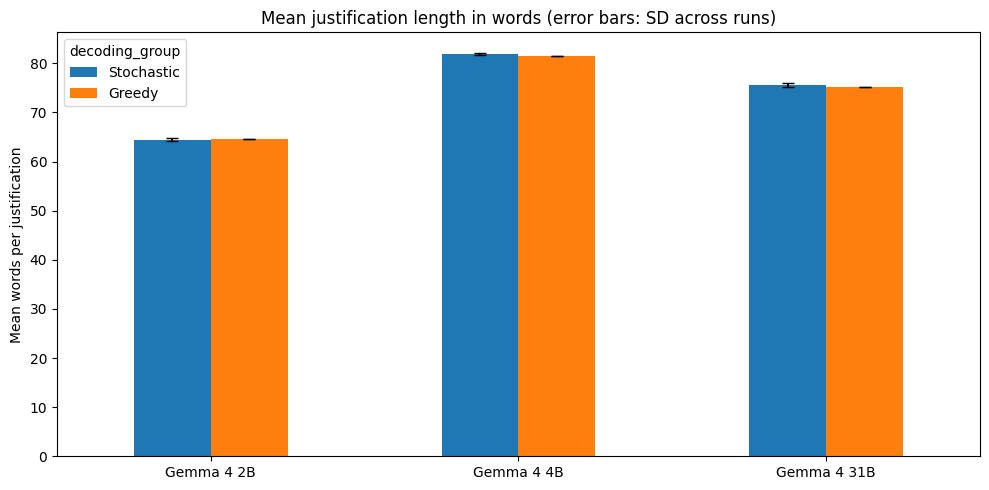

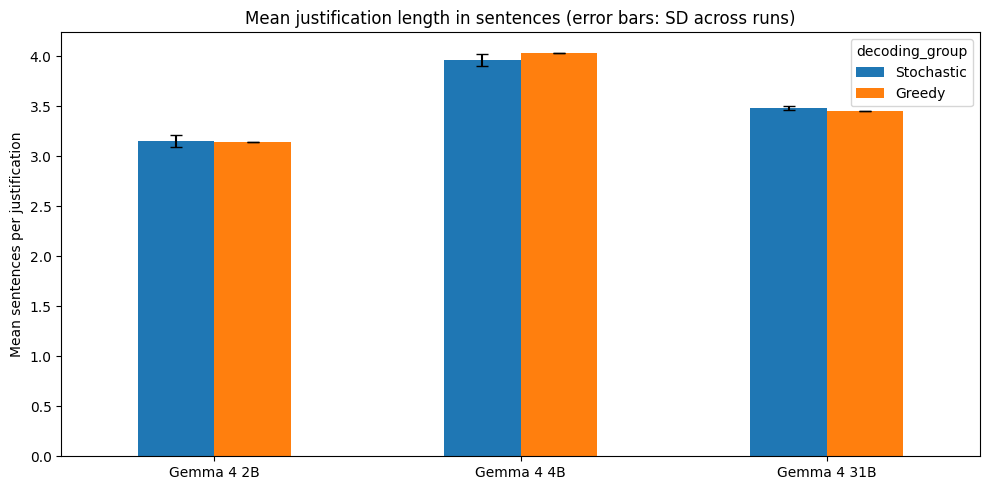

In [11]:
# ============================================================
# 10. Plot justification length
# ============================================================

def plot_overall_metric(
    dataframe,
    mean_column,
    std_column,
    title,
    ylabel,
):
    mean_df = (
        dataframe
        .pivot(
            index="model",
            columns="decoding_group",
            values=mean_column,
        )
        .reindex(
            index=MODEL_ORDER,
            columns=DECODING_ORDER,
        )
    )

    std_df = (
        dataframe
        .pivot(
            index="model",
            columns="decoding_group",
            values=std_column,
        )
        .reindex(
            index=MODEL_ORDER,
            columns=DECODING_ORDER,
        )
        .fillna(0)
    )

    ax = mean_df.plot(
        kind="bar",
        yerr=std_df,
        capsize=4,
        figsize=(10, 5),
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()


plot_overall_metric(
    overall_summary_df,
    mean_column="mean_words",
    std_column="std_mean_words",
    title=(
        "Mean justification length in words "
        "(error bars: SD across runs)"
    ),
    ylabel="Mean words per justification",
)

plot_overall_metric(
    overall_summary_df,
    mean_column="mean_sentences",
    std_column="std_mean_sentences",
    title=(
        "Mean justification length in sentences "
        "(error bars: SD across runs)"
    ),
    ylabel="Mean sentences per justification",
)


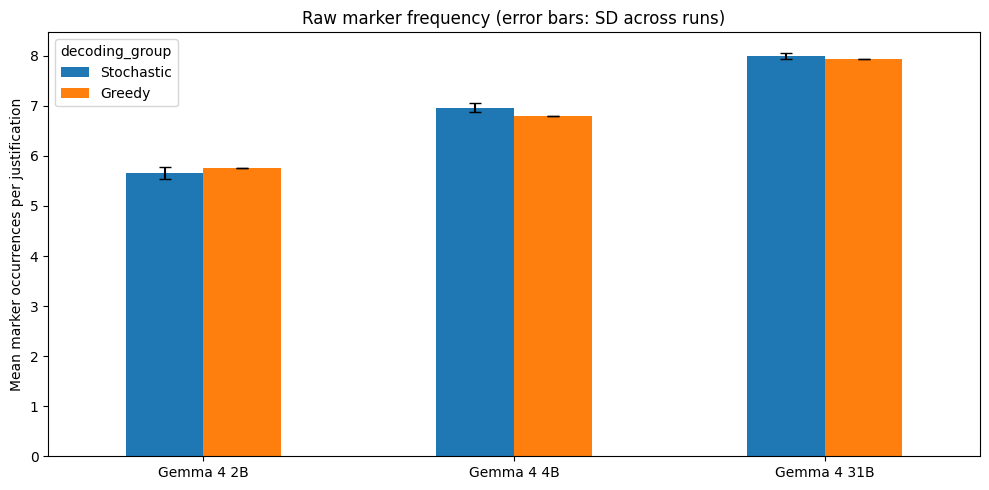

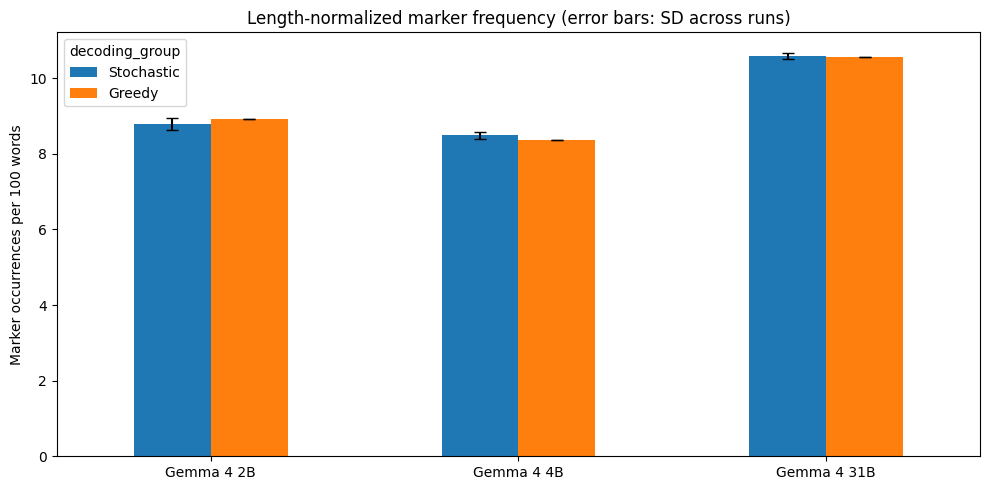

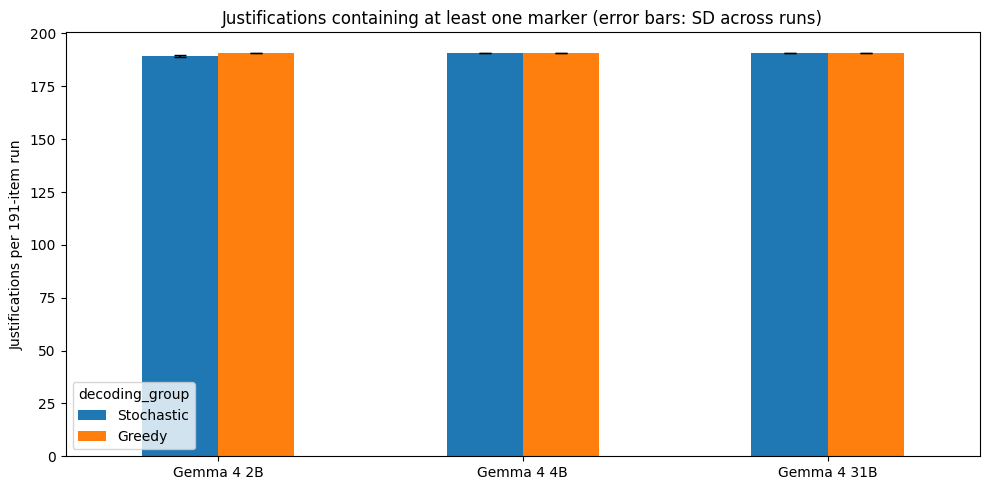

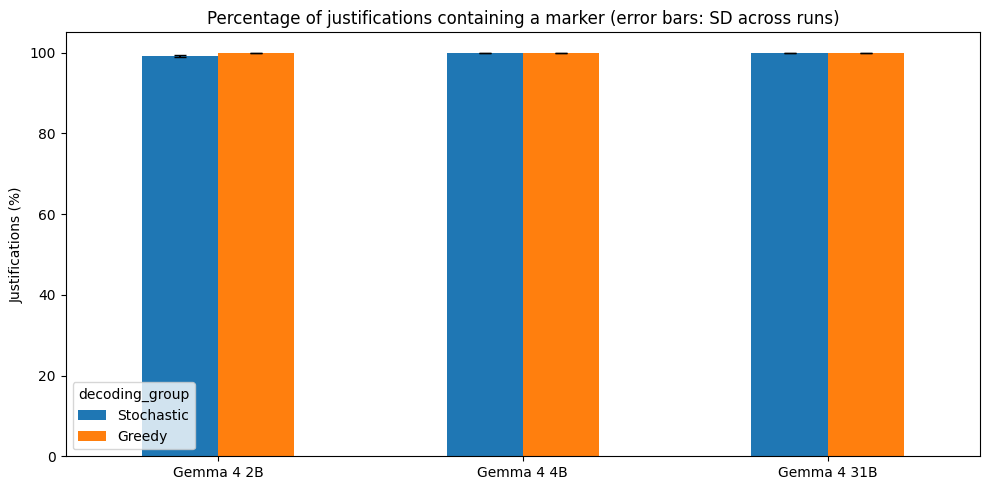

In [12]:
# ============================================================
# 11. Plot overall marker frequency and coverage
# ============================================================

plot_overall_metric(
    overall_summary_df,
    mean_column="mean_markers_per_justification",
    std_column="std_markers_per_justification",
    title=(
        "Raw marker frequency "
        "(error bars: SD across runs)"
    ),
    ylabel="Mean marker occurrences per justification",
)

plot_overall_metric(
    overall_summary_df,
    mean_column="mean_markers_per_100_words",
    std_column="std_markers_per_100_words",
    title=(
        "Length-normalized marker frequency "
        "(error bars: SD across runs)"
    ),
    ylabel="Marker occurrences per 100 words",
)

plot_overall_metric(
    overall_summary_df,
    mean_column=(
        "mean_justifications_with_marker_per_run"
    ),
    std_column=(
        "std_justifications_with_marker_per_run"
    ),
    title=(
        "Justifications containing at least one marker "
        "(error bars: SD across runs)"
    ),
    ylabel="Justifications per 191-item run",
)

plot_overall_metric(
    overall_summary_df,
    mean_column=(
        "mean_pct_justifications_with_marker"
    ),
    std_column=(
        "std_pct_justifications_with_marker"
    ),
    title=(
        "Percentage of justifications containing a marker "
        "(error bars: SD across runs)"
    ),
    ylabel="Justifications (%)",
)


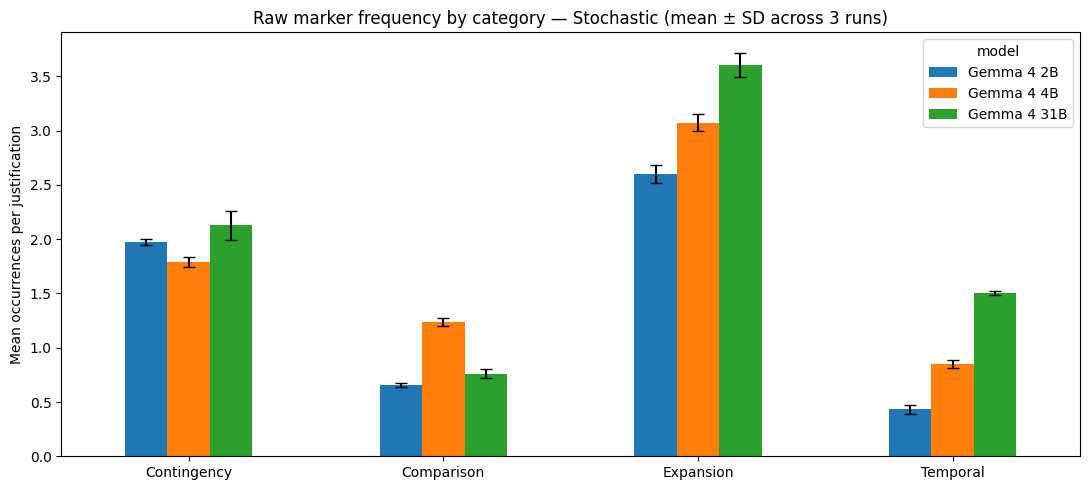

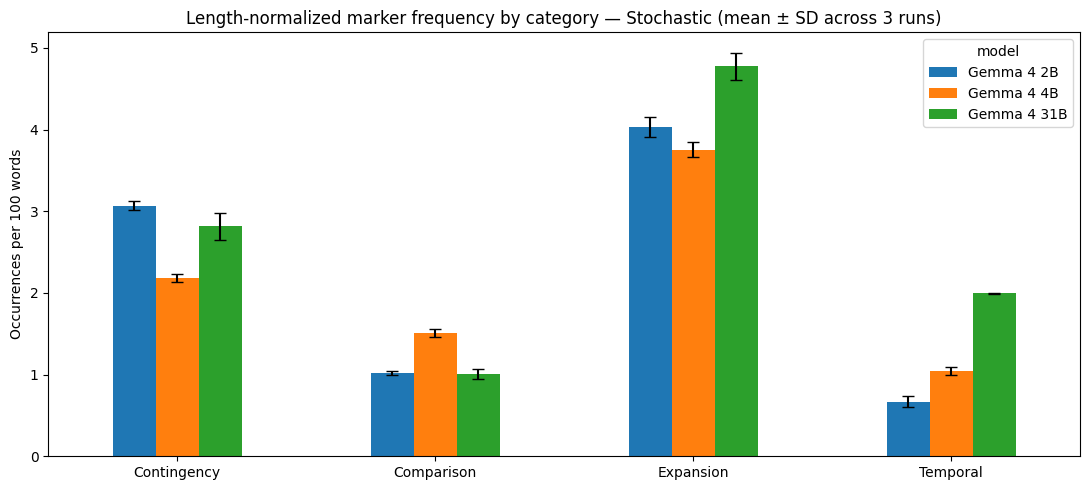

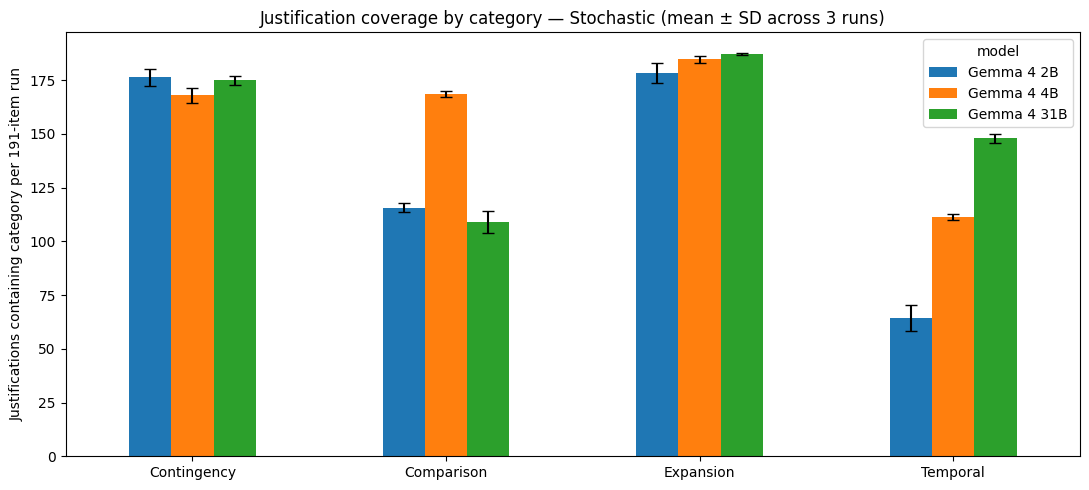

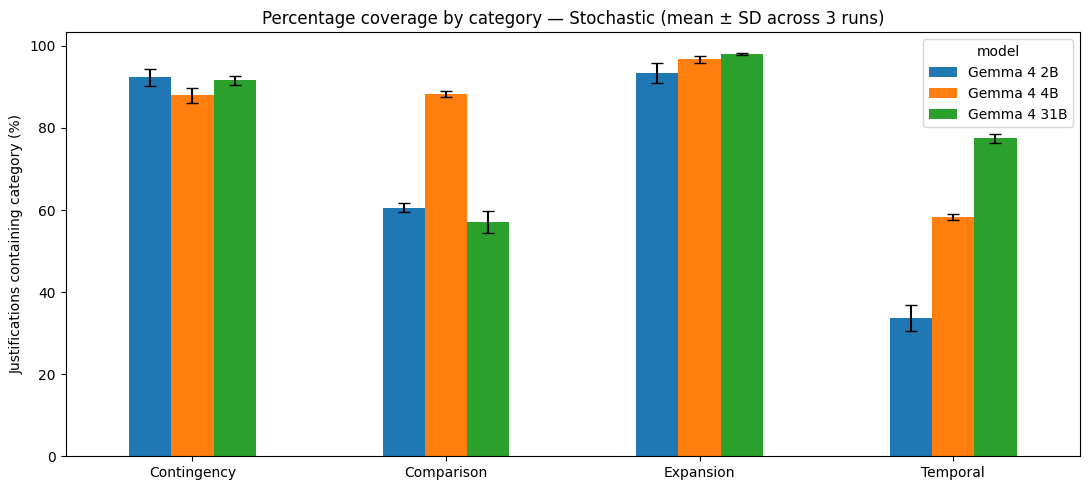

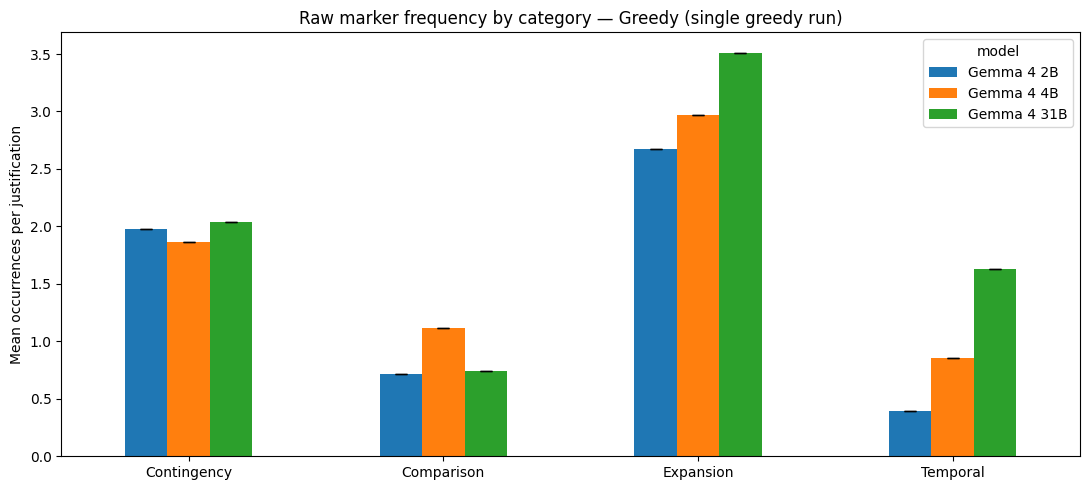

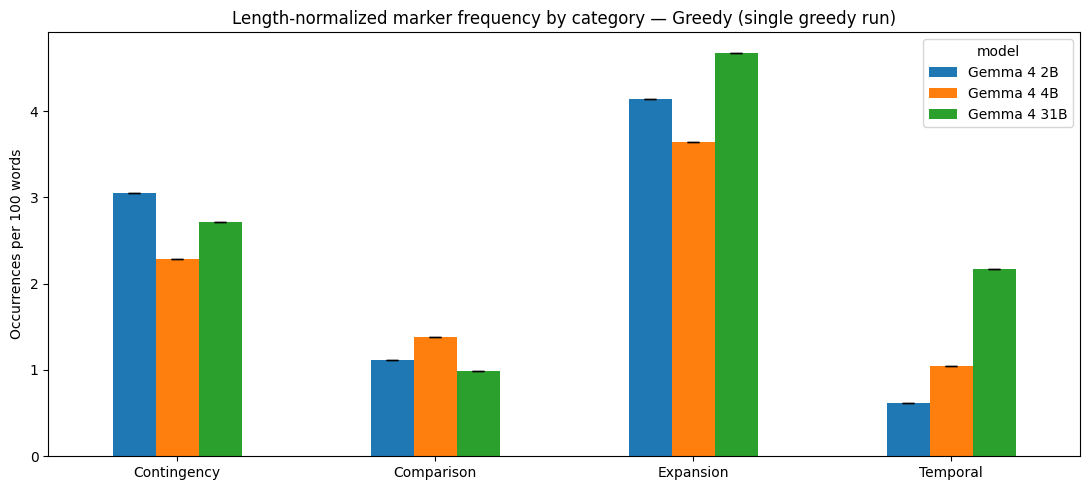

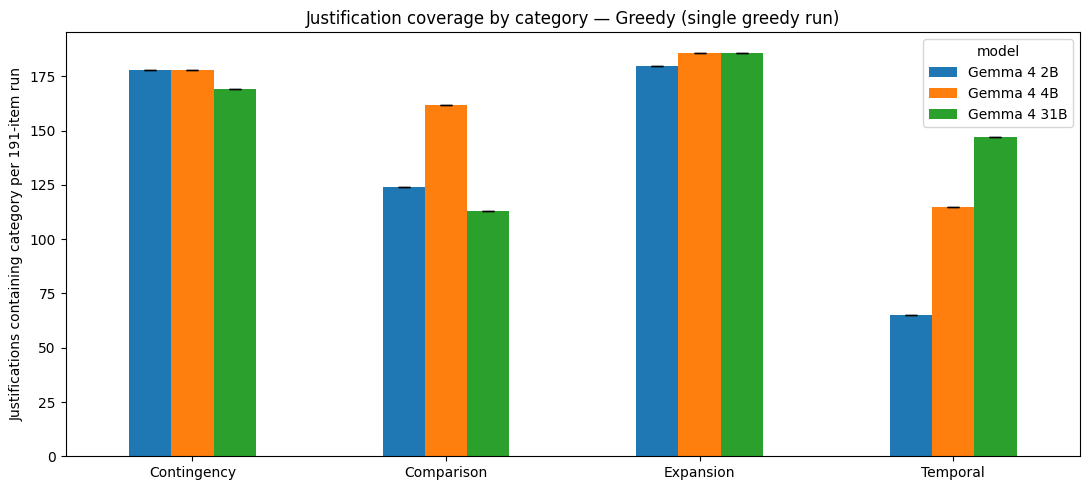

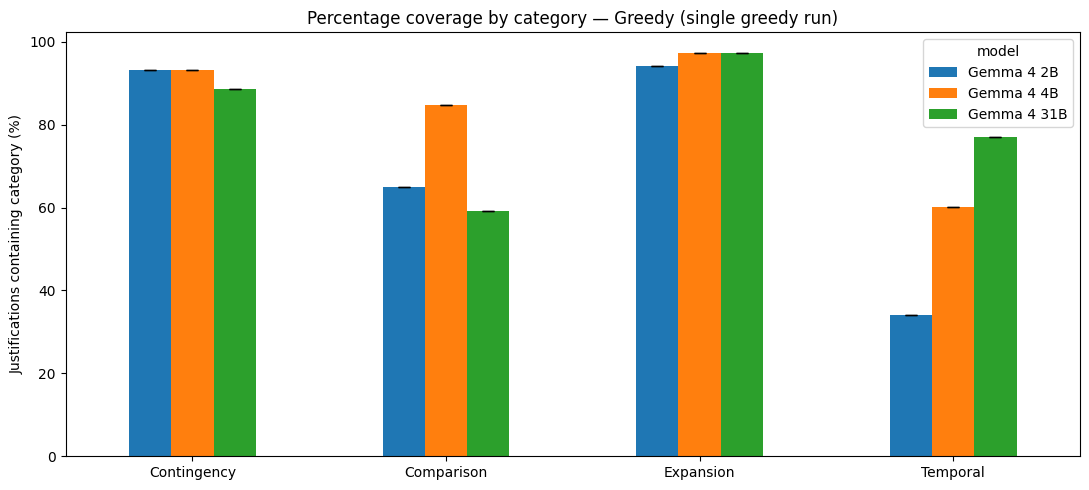

In [13]:
# ============================================================
# 12. Plot category frequency and category coverage
# ============================================================

CATEGORY_ORDER = [
    "Contingency",
    "Comparison",
    "Expansion",
    "Temporal",
]


def plot_category_metric(
    decoding_group,
    mean_column,
    std_column,
    title,
    ylabel,
):
    selected_df = category_summary_df.loc[
        category_summary_df[
            "decoding_group"
        ].astype(str).eq(decoding_group)
    ]

    mean_df = (
        selected_df
        .pivot_table(
            index="category",
            columns="model",
            values=mean_column,
            observed=False,
        )
        .reindex(
            index=CATEGORY_ORDER,
            columns=MODEL_ORDER,
        )
    )

    std_df = (
        selected_df
        .pivot_table(
            index="category",
            columns="model",
            values=std_column,
            observed=False,
        )
        .reindex(
            index=CATEGORY_ORDER,
            columns=MODEL_ORDER,
        )
        .fillna(0)
    )

    ax = mean_df.plot(
        kind="bar",
        yerr=std_df,
        capsize=4,
        figsize=(11, 5),
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()


for decoding_group in DECODING_ORDER:
    suffix = (
        "mean ± SD across 3 runs"
        if decoding_group == "Stochastic"
        else "single greedy run"
    )

    # Frequency: repeated uses in the same justification count.
    plot_category_metric(
        decoding_group,
        mean_column=(
            "mean_occurrences_per_justification"
        ),
        std_column=(
            "std_occurrences_per_justification"
        ),
        title=(
            "Raw marker frequency by category — "
            f"{decoding_group} ({suffix})"
        ),
        ylabel=(
            "Mean occurrences per justification"
        ),
    )

    plot_category_metric(
        decoding_group,
        mean_column=(
            "mean_occurrences_per_100_words"
        ),
        std_column=(
            "std_occurrences_per_100_words"
        ),
        title=(
            "Length-normalized marker frequency "
            f"by category — {decoding_group} ({suffix})"
        ),
        ylabel=(
            "Occurrences per 100 words"
        ),
    )

    # Coverage: each category counts once per justification.
    plot_category_metric(
        decoding_group,
        mean_column=(
            "mean_justifications_with_item_per_run"
        ),
        std_column=(
            "std_justifications_with_item_per_run"
        ),
        title=(
            "Justification coverage by category — "
            f"{decoding_group} ({suffix})"
        ),
        ylabel=(
            "Justifications containing category "
            "per 191-item run"
        ),
    )

    plot_category_metric(
        decoding_group,
        mean_column=(
            "mean_pct_justifications_with_item"
        ),
        std_column=(
            "std_pct_justifications_with_item"
        ),
        title=(
            "Percentage coverage by category — "
            f"{decoding_group} ({suffix})"
        ),
        ylabel=(
            "Justifications containing category (%)"
        ),
    )


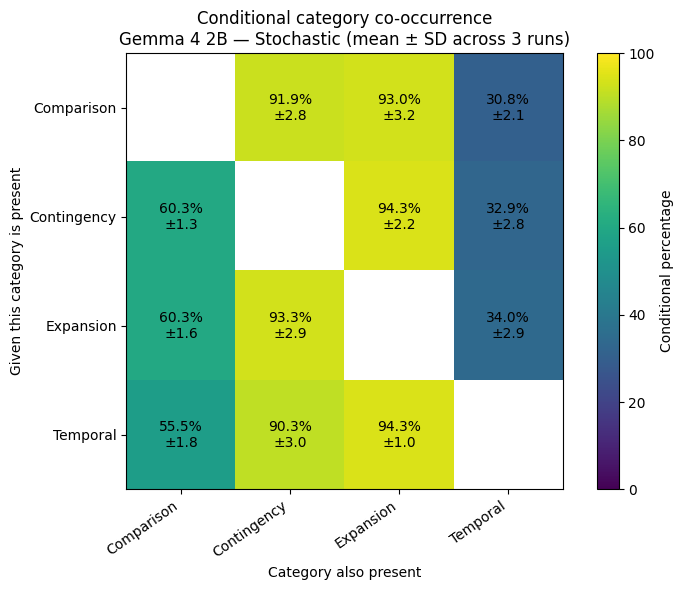

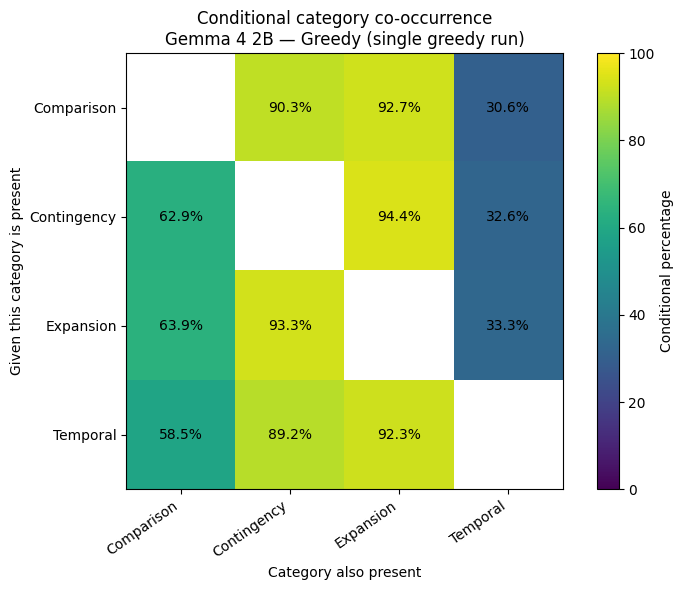

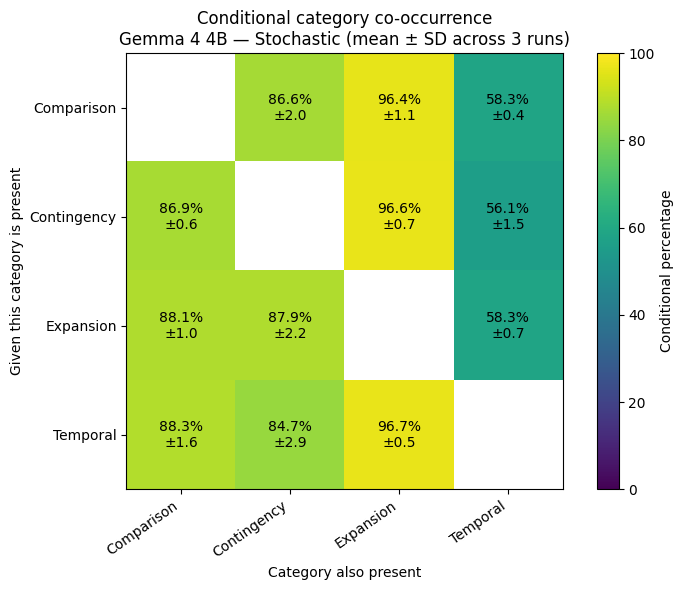

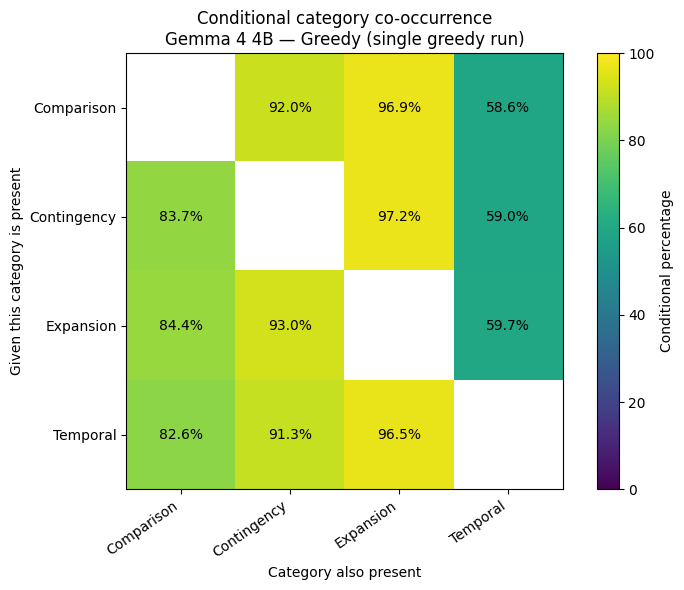

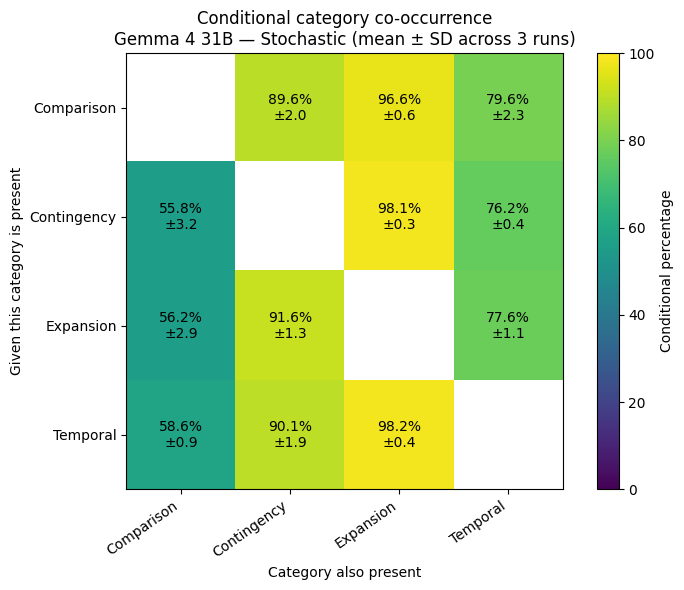

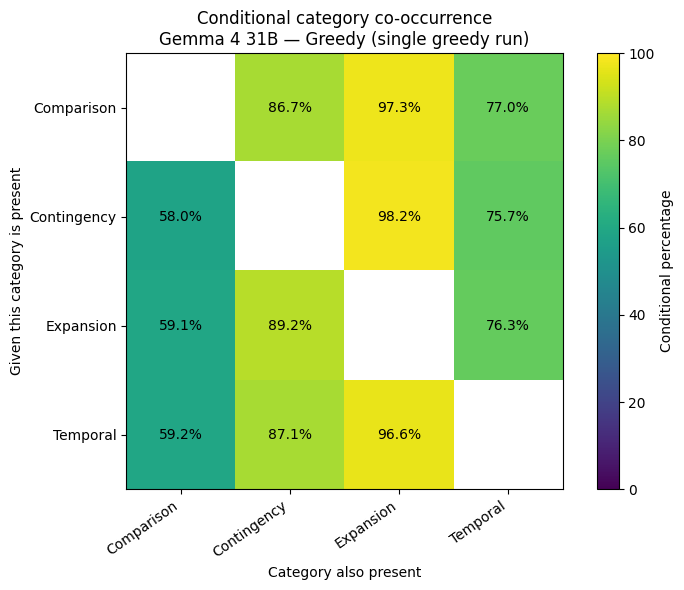

In [14]:
# ============================================================
# 13. Plot directional conditional co-occurrence matrices
# ============================================================

def plot_conditional_matrix(
    mean_matrix,
    std_matrix,
    n_runs,
    title,
):
    values = mean_matrix.to_numpy(dtype=float)
    std_values = std_matrix.to_numpy(dtype=float)

    masked_values = np.ma.masked_invalid(
        values
    )

    plt.figure(figsize=(8, 6))
    plt.imshow(
        masked_values,
        vmin=0,
        vmax=100,
    )

    plt.xticks(
        range(len(mean_matrix.columns)),
        mean_matrix.columns,
        rotation=35,
        ha="right",
    )

    plt.yticks(
        range(len(mean_matrix.index)),
        mean_matrix.index,
    )

    for row_index in range(values.shape[0]):
        for column_index in range(values.shape[1]):
            mean_value = values[
                row_index,
                column_index,
            ]

            if np.isnan(mean_value):
                continue

            if (
                n_runs > 1
                and not np.isnan(
                    std_values[
                        row_index,
                        column_index,
                    ]
                )
            ):
                label = (
                    f"{mean_value:.1f}%\n"
                    f"±{std_values[row_index, column_index]:.1f}"
                )
            else:
                label = f"{mean_value:.1f}%"

            plt.text(
                column_index,
                row_index,
                label,
                ha="center",
                va="center",
            )

    plt.title(title)
    plt.xlabel("Category also present")
    plt.ylabel("Given this category is present")
    plt.colorbar(
        label="Conditional percentage"
    )
    plt.tight_layout()
    plt.show()


for model_name in MODEL_ORDER:
    for decoding_group in DECODING_ORDER:
        result = conditional_cooccurrence_summary[
            (model_name, decoding_group)
        ]

        aggregation_label = (
            "mean ± SD across 3 runs"
            if result["n_runs"] > 1
            else "single greedy run"
        )

        plot_conditional_matrix(
            mean_matrix=(
                result["mean_percentages"]
            ),
            std_matrix=(
                result["std_percentages"]
            ),
            n_runs=result["n_runs"],
            title=(
                "Conditional category co-occurrence\n"
                f"{model_name} — {decoding_group} "
                f"({aggregation_label})"
            ),
        )


## Extension: normalized rates, sensitivity checks, conditioned comparisons

Self-contained (reloads inputs), so it runs even on a fresh kernel. All
cross-model comparisons use **markers per 100 words**, computed per
justification, averaged per game, then across games (equal game weighting).
Raw counts stay available upstream. Includes: (1) normalized category rates
per model x decoding, (2) Temporal with and without the polysemous marker
"as" (mostly non-temporal in context), (3) Temporal rate conditioned on
night-swap games (where sequence reasoning is actually needed), and
(4) Contingency rate by vote correctness. Marker matching = case-insensitive
word-boundary regex, longest-match spans blocked from double counting.
Caveat carried throughout: markers measure the rhetoric of reasoning, not
reasoning; faithfulness remains open.

In [15]:

# --- EXT 1: self-contained load ---
from pathlib import Path
import json as _json, re as _re
import numpy as _np, pandas as _pd
import matplotlib.pyplot as _plt

_ROOT = Path.cwd()
while _ROOT.name != "masters_thesis_sdg":
    _ROOT = _ROOT.parent
_AN = _ROOT / "analysis"
_REL = Path("base/voting/prompt_v4/vote_stability/tables")
_MK = _pd.read_csv(_ROOT / "data" / "processed" / "dimlex_marker_assignments.csv") \
    if (_ROOT / "data" / "processed" / "dimlex_marker_assignments.csv").exists() else \
    _pd.read_csv(sorted(_ROOT.rglob("dimlex_marker_assignments.csv"))[0])
_cat_col = [c for c in _MK.columns if "categ" in c.lower()][-1]
MARKERS = {str(r["marker"]).lower(): r[_cat_col] for _, r in _MK.iterrows()}
CATS = sorted(set(MARKERS.values()))
_pats = sorted(MARKERS, key=len, reverse=True)
_rx = _re.compile(r"\b(" + "|".join(_re.escape(m) for m in _pats) + r")\b", _re.I)

def _label(name):
    m = _re.search(r"(\d+B)", name); return m.group(1) if m else name

_rows, _roles = [], {}
for d in sorted(_AN.iterdir()):
    fl = d / _REL / "llm_vote_file_level.csv"
    if not fl.exists(): continue
    mdl = _label(d.name)
    f = _pd.read_csv(fl); f["model"] = mdl
    _rows.append(f)
    g = _pd.read_csv(d / _REL / "llm_vote_game_level.csv")
    for _, r in g.iterrows():
        try:
            sw = set(_json.loads(r["start_roles"])and[n for n,ro in zip(_json.loads(r["player_names"]),_json.loads(r["start_roles"])) if ro=="Werewolf"]) != \
                 set([n for n,ro in zip(_json.loads(r["player_names"]),_json.loads(r["end_roles"])) if ro=="Werewolf"])
        except Exception:
            sw = False
        _roles[r["game_id"]] = sw
_J = _pd.concat(_rows, ignore_index=True)
_J = _J[_J["justification"].notna()].copy()
_J["decoding_group"] = _np.where(
    _J["decoding"].astype(str).str.lower().eq("stochastic"), "Stochastic", "Greedy")
_J["n_words"] = _J["justification"].astype(str).str.split().str.len().clip(lower=1)
for c in CATS: _J[f"n_{c}"] = 0
_tmp = {c: [] for c in CATS}
for t in _J["justification"].astype(str):
    cnt = {c: 0 for c in CATS}
    for m in _rx.finditer(t.lower()):
        cnt[MARKERS[m.group(1).lower()]] += 1
    for c in CATS: _tmp[c].append(cnt[c])
for c in CATS: _J[f"n_{c}"] = _tmp[c]
for c in CATS: _J[f"rate_{c}"] = 100 * _J[f"n_{c}"] / _J["n_words"]
_J["swap_game"] = _J["game_id"].map(_roles).fillna(False)
print(f"justifications: {len(_J)}; mean words by model:",
      _J.groupby("model")["n_words"].mean().round(1).to_dict())


justifications: 2287; mean words by model: {'2B': 64.9, '31B': 75.4, '4B': 81.7}


In [16]:

# --- EXT 2: normalized category rates (per game, then across games) ---
def _game_then_mean(df, cols):
    return df.groupby(["model","decoding_group","game_id"])[cols].mean() \
             .groupby(["model","decoding_group"]).mean()
_rate_cols = [f"rate_{c}" for c in CATS]
norm_rates = _game_then_mean(_J, _rate_cols).round(3)
print("Markers per 100 words (equal game weighting):"); display(norm_rates)

# 'as' sensitivity: Temporal recomputed excluding 'as'
_rx_as = _re.compile(r"\bas\b", _re.I)
_J["n_as"] = _J["justification"].astype(str).str.lower().str.count(r"\bas\b")
if "Temporal" in CATS and MARKERS.get("as") == "Temporal":
    _J["rate_Temporal_noas"] = 100 * (_J["n_Temporal"] - _J["n_as"]).clip(lower=0) / _J["n_words"]
    t = _game_then_mean(_J, ["rate_Temporal", "rate_Temporal_noas"]).round(3)
    print("Temporal rate with vs without 'as':"); display(t)
else:
    print("'as' not assigned to Temporal in this lexicon -- no sensitivity issue.")


Markers per 100 words (equal game weighting):


rate_Comparison  rate_Contingency  rate_Expansion  \
model decoding_group                                                      
2B    Greedy                    1.104             3.053           4.087   
      Stochastic                1.008             3.095           3.986   
31B   Greedy                    0.967             2.717           4.647   
      Stochastic                1.002             2.809           4.773   
4B    Greedy                    1.374             2.310           3.626   
      Stochastic                1.515             2.198           3.734   

                      rate_Temporal  
model decoding_group                 
2B    Greedy                  0.644  
      Stochastic              0.681  
31B   Greedy                  2.153  
      Stochastic              2.002  
4B    Greedy                  1.050  
      Stochastic              1.052

Temporal rate with vs without 'as':


rate_Temporal  rate_Temporal_noas
model decoding_group                                   
2B    Greedy                  0.644               0.211
      Stochastic              0.681               0.235
31B   Greedy                  2.153               0.899
      Stochastic              2.002               0.806
4B    Greedy                  1.050               0.480
      Stochastic              1.052               0.463

In [17]:

# --- EXT 3: conditioned comparisons + save ---
if "Temporal" in CATS:
    tcol = "rate_Temporal_noas" if "rate_Temporal_noas" in _J.columns else "rate_Temporal"
    tmp = _J.groupby(["model","decoding_group","swap_game","game_id"])[tcol].mean() \
            .groupby(["model","decoding_group","swap_game"]).agg(["mean","count"]).round(3)
    print(f"{tcol} by night-swap games (sequence reasoning needed vs not):"); display(tmp)
if "Contingency" in CATS and "is_correct" in _J.columns:
    sub = _J[_J["is_correct"].notna()]
    cg = sub.groupby(["model","decoding_group","is_correct","game_id"])["rate_Contingency"].mean() \
            .groupby(["model","decoding_group","is_correct"]).agg(["mean","count"]).round(3)
    print("Contingency rate by vote correctness:"); display(cg)

_OUT = _AN / "cross_model" / "voting" / "prompt_v4" / "justification_analysis" / "tables"
_OUT.mkdir(parents=True, exist_ok=True)
norm_rates.to_csv(_OUT / "normalized_marker_rates_per100w.csv")
if "rate_Temporal_noas" in _J.columns:
    t.to_csv(_OUT / "temporal_as_sensitivity.csv")
    tmp.to_csv(_OUT / "temporal_by_swap_games.csv")
if "Contingency" in CATS:
    cg.to_csv(_OUT / "contingency_by_correctness.csv")
print("saved ->", _OUT)


rate_Temporal_noas by night-swap games (sequence reasoning needed vs not):


mean  count
model decoding_group swap_game              
2B    Greedy         False      0.216    118
                     True       0.203     73
      Stochastic     False      0.225    118
                     True       0.250     73
31B   Greedy         False      0.895    118
                     True       0.906     73
      Stochastic     False      0.784    118
                     True       0.841     73
4B    Greedy         False      0.428    118
                     True       0.564     73
      Stochastic     False      0.372    118
                     True       0.609     73

Contingency rate by vote correctness:


mean  count
model decoding_group is_correct              
2B    Greedy         False       2.988    121
                     True        3.164     70
      Stochastic     False       3.072    146
                     True        3.098    110
31B   Greedy         False       2.743    107
                     True        2.684     84
      Stochastic     False       2.724    135
                     True        2.844    105
4B    Greedy         False       2.254    113
                     True        2.391     78
      Stochastic     False       2.122    136
                     True        2.238    107

saved -> c:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\cross_model\voting\prompt_v4\justification_analysis\tables


### Bootstrap CIs on the conditioned comparisons

The swap-game and correctness contrasts above are small, so they get 95%
percentile bootstrap CIs before any of them is narrated. Games are the
resampling unit (per-game means computed first), and the two groups are
resampled independently since they are different games -- not paired. A
difference whose CI includes 0 is not reportable as real at this n.

In [18]:

# --- EXT 4: bootstrap CIs for the conditioned contrasts ---
_NB, _ALPHA = 5000, 0.05
_rng_boot = _np.random.default_rng(0)

def _boot_diff(a, b, n_boot=_NB, alpha=_ALPHA):
    """95% percentile CI for mean(a) - mean(b); a, b are per-game values."""
    a, b = _np.asarray(a, float), _np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return _np.nan, _np.nan, _np.nan
    da = a[_rng_boot.integers(0, len(a), (n_boot, len(a)))].mean(1)
    db = b[_rng_boot.integers(0, len(b), (n_boot, len(b)))].mean(1)
    d = da - db
    lo, hi = _np.percentile(d, [100*alpha/2, 100*(1-alpha/2)])
    return float(a.mean() - b.mean()), float(lo), float(hi)


def _contrast_table(value_col, split_col, label_true, label_false):
    per_game = (_J.groupby(["model", "decoding_group", split_col, "game_id"])[value_col]
                  .mean().reset_index())
    rows = []
    for (mdl, dg), grp in per_game.groupby(["model", "decoding_group"]):
        a = grp.loc[grp[split_col] == True, value_col].values
        b = grp.loc[grp[split_col] == False, value_col].values
        diff, lo, hi = _boot_diff(a, b)
        rows.append({"model": mdl, "decoding": dg,
                     f"n_{label_true}": len(a), f"n_{label_false}": len(b),
                     f"mean_{label_true}": round(float(a.mean()), 3) if len(a) else _np.nan,
                     f"mean_{label_false}": round(float(b.mean()), 3) if len(b) else _np.nan,
                     "diff": round(diff, 3), "ci_low": round(lo, 3), "ci_high": round(hi, 3),
                     "excludes_zero": bool(lo > 0 or hi < 0)})
    return _pd.DataFrame(rows)


_tcol = "rate_Temporal_noas" if "rate_Temporal_noas" in _J.columns else "rate_Temporal"
temporal_ci = _contrast_table(_tcol, "swap_game", "swap", "noswap")
print(f"{_tcol}: swap games minus non-swap games (95% bootstrap CI over games):")
display(temporal_ci)

if "Contingency" in CATS and "is_correct" in _J.columns:
    _J["_correct"] = _J["is_correct"].astype("boolean")
    _sub = _J[_J["_correct"].notna()].copy()
    _sub["_correct"] = _sub["_correct"].astype(bool)
    _keep, _J_full = _J, _J
    _J = _sub                      # reuse the helper on the filtered frame
    contingency_ci = _contrast_table("rate_Contingency", "_correct", "correct", "wrong")
    _J = _J_full
    print("rate_Contingency: correct votes minus wrong votes (95% bootstrap CI over games):")
    display(contingency_ci)

temporal_ci.to_csv(_OUT / "temporal_by_swap_bootstrap_ci.csv", index=False)
if "Contingency" in CATS and "is_correct" in _J.columns:
    contingency_ci.to_csv(_OUT / "contingency_by_correctness_bootstrap_ci.csv", index=False)
print("saved bootstrap CI tables ->", _OUT)


rate_Temporal_noas: swap games minus non-swap games (95% bootstrap CI over games):


,model,decoding,n_swap,n_noswap,mean_swap,mean_noswap,diff,ci_low,ci_high,excludes_zero
0,2B,Greedy,73,118,0.203,0.216,-0.013,-0.179,0.173,False
1,2B,Stochastic,73,118,0.250,0.225,0.024,-0.088,0.137,False
2,31B,Greedy,73,118,0.906,0.895,0.012,-0.303,0.339,False
3,31B,Stochastic,73,118,0.841,0.784,0.057,-0.148,0.271,False
4,4B,Greedy,73,118,0.564,0.428,0.135,-0.097,0.362,False
5,4B,Stochastic,73,118,0.609,0.372,0.237,0.085,0.390,True


rate_Contingency: correct votes minus wrong votes (95% bootstrap CI over games):


,model,decoding,n_correct,n_wrong,mean_correct,mean_wrong,diff,ci_low,ci_high,excludes_zero
0,2B,Greedy,70,121,3.164,2.988,0.176,-0.315,0.661,False
1,2B,Stochastic,110,146,3.098,3.072,0.026,-0.323,0.378,False
2,31B,Greedy,84,107,2.684,2.743,-0.059,-0.533,0.439,False
3,31B,Stochastic,105,135,2.844,2.724,0.120,-0.220,0.474,False
4,4B,Greedy,78,113,2.391,2.254,0.137,-0.268,0.529,False
5,4B,Stochastic,107,136,2.238,2.122,0.116,-0.148,0.383,False


saved bootstrap CI tables -> c:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\cross_model\voting\prompt_v4\justification_analysis\tables
